#  AIC354 — Machine Learning Fundamentals Lab
## End-to-End House Price Prediction System — Islamabad

| Field | Details |
|---|---|
| **Course** | AIC354 — Machine Learning Fundamentals |
| **Instructor** | Mr. Anayat Ullah |
| **Submitted by** | Hasnat khan |
| **Reg no** | SP24-BCS-039 |
| **Dataset** | Zameen.com — Islamabad Property Listings |
| **Models** | Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, CatBoost |

---

### Pipeline Overview
```
Raw CSV  →  Preprocessing  →  Feature Engineering  →  Model Training  →  Evaluation  →  Prediction
```



#### Note: Hyperparameter tuning may take approximately 12-15 minutes on Google Colab depending on available resources and runtime configuration. i used the maximum possible epochs so that max accuracy came
### Note: More than mine accuracy(91%) on real dataset is very hard 
### Note: Scrapper file is not here as we dont scrap the data from zameen.com everytime so we use the seprate file for the scraping

### How To Run This Project

1. Keep these files in the same folder:
   - `ml_pipeline.ipynb`
   - `zameen_islamabad.csv`
   - `zameen_scraper.py`
   - `predict.py`
   - `app.py`
   - Model files such as `best_model.pkl`, `feature_cols.pkl`, and encoder/map `.pkl` files

2. Install required libraries if needed:
   ```bash
   pip install -r requirements.txt

# Project Submission Structure

```text
FA22-BCS-XXX.zip
│
├── Required Submission Files
│   │
│   ├── Scraper_code.py
│   │      └── Scraper code
│   │
│   ├── zameen_islamabad.csv
│   │      └── Dataset
│   │
│   ├── ml_pipeline.ipynb
│   │      └── Training code
│   │
│   ├── ML_House_Price_Report_Hasnat.docx
│   │      └── Final report
│   │
│   └── GUI_Prediction_System.py
│          └── GUI / Prediction system
│
├── GUI Supporting Files
│   │
│   ├── requirements.txt
│   ├── GUI_requirements.txt
│   ├── README.md
│   │
│   ├── best_model.pkl
│   ├── feature_cols.pkl
│   ├── global_median.pkl
│   ├── loc_freq_map.pkl
│   └── loc_median_map.pkl
│
└── Optional / Auto-generated Files
    │
    ├── __pycache__      (not required for submission)
    └── catboost_info    (not required for submission)
```

**Note:**  
The `.pkl` files are supporting model artifacts generated separately for the GUI prediction system and are included so that the GUI can directly load trained model information without retraining each time.

## CLO Implementation Summary - Table of Contents

- [CLO-1: Data Acquisition and Web Scraping](#clo-1-data-acquisition-and-web-scraping)
- [CLO-2: Data Preprocessing and Feature Engineering](#clo-2-data-preprocessing-and-feature-engineering)
- [CLO-3: Machine Learning Model Development](#clo-3-machine-learning-model-development)
- [CLO-4: Model Evaluation and Performance Analysis](#clo-4-model-evaluation-and-performance-analysis)
- [CLO-5: End-to-End System Development](#clo-5-end-to-end-system-development)

##  Step 0 — Install & Configure Environment

In [1]:
!pip install xgboost catboost

Defaulting to user installation because normal site-packages is not writeable


### 0.1 - All required lib importing

In [2]:
import importlib
import subprocess
import sys
import time
import warnings
import re
import pickle

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scikit-learn': 'sklearn',
    'xgboost': 'xgboost',
    'catboost': 'catboost'
}

for package, module in required_packages.items():

    try:
        importlib.import_module(module)
        print(f'{package:<14} ready')

    except Exception:
        print(f'Installing {package}...')

        subprocess.check_call([
            sys.executable,
            '-m',
            'pip',
            'install',
            package,
            '-q'
        ])

print('All required packages ready')

%matplotlib inline

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    RandomizedSearchCV
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import r2_score as _r2

pandas         ready
numpy          ready
matplotlib     ready
seaborn        ready
scikit-learn   ready
xgboost        ready
catboost       ready
All required packages ready


### 0.2 -Visualization Configuration

In [3]:
plt.rcParams.update({
    'figure.dpi'      : 120,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.alpha'      : 0.4,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
})
PALETTE = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4',
           '#795548','#607D8B']
print('Imports successful')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
import sklearn; print(f'   sklearn {sklearn.__version__}')


Imports successful
   pandas  2.3.1
   numpy   2.3.2
   sklearn 1.8.0


---
## CLO-1: Data Acquisition and Web Scraping
Load the CSV scraped from Zameen.com and perform an initial inspection.

In [4]:
import os
import pandas as pd

try:
    import google.colab
    from google.colab import files

    print("Google Colab detected → Please upload zameen_islamabad.csv")
    uploaded = files.upload()

    csv_file = "zameen_islamabad.csv"

except ImportError:
    print("Local environment detected → Loading CSV from current folder")
    csv_file = "zameen_islamabad.csv"

if not os.path.exists(csv_file):
    raise FileNotFoundError(
        f"{csv_file} not found. Please upload it (Colab) or place it in the same folder."
    )

df = pd.read_csv(csv_file)

print("━"*50)
print(f"Rows      : {df.shape[0]}")
print(f"Columns   : {df.shape[1]}")
print("━"*50)

df.head(8)

Local environment detected → Loading CSV from current folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Rows      : 500
Columns   : 20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,city,title,price,area,location,property_type,bedrooms,bathrooms,built_in_year,parking_space,servant_quarters,store_rooms,kitchens,drawing_room,dining_room,study_room,prayer_room,powder_room,lounge_sitting_room,url
0,Islamabad,1 Kanal Modern Luxury House For Sale In DHA Ph...,138000000.0,1 Kanal,"DHA Defence, Islamabad, Islamabad Capital",House,5.0,6.0,2026,2,2,2,2,Yes,Yes,Yes,Yes,Yes,Yes,https://www.zameen.com/Property/dha_defence_dh...
1,Islamabad,Luxurious 8 Marla Triple-Sided Open Home with ...,42500000.0,8 Marla,"Bahria Town, Islamabad, Islamabad Capital",House,5.0,7.0,2026,Yes,1,2,2,Yes,Yes,Yes,Yes,Yes,Yes,https://www.zameen.com/Property/bahria_enclave...
2,Islamabad,20 MARLA CORNER DOUBLE UNIT HOUSE FOR SALE IN ...,77000000.0,1 Kanal,"DHA Defence, Islamabad, Islamabad Capital",House,8.0,6.0,2016,2016,3,4,3,Yes,Yes,NaN,NaN,Yes,Yes,https://www.zameen.com/Property/dha_defence_dh...
3,Islamabad,Sector N 5 Marla Brand New Corner House With 2...,32000000.0,7 Marla,"Bahria Town, Islamabad, Islamabad Capital",House,4.0,6.0,2024,1,1,1,2,Yes,Yes,Yes,Yes,Yes,Yes,https://www.zameen.com/Property/bahria_enclave...
4,Islamabad,Corner 10 Marla Semi Furnished House For Sale,63500000.0,10 Marla,"Top City 1, Islamabad, Islamabad Capital",House,6.0,6.0,2026,2,1,1,2,Yes,Yes,Yes,Yes,NaN,NaN,https://www.zameen.com/Property/islamabad_top_...
5,Islamabad,Prime Location Studio Furnished Apartment For ...,7200000.0,2.2 Marla,"Islamabad Expressway, Islamabad, Islamabad Cap...",Flat,NaN,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.zameen.com/Property/islamabad_isla...
6,Islamabad,Prime Location 2 Bed Furnished Apartment For Sale,17200000.0,4.9 Marla,"Islamabad Expressway, Islamabad, Islamabad Cap...",Flat,2.0,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.zameen.com/Property/islamabad_isla...
7,Islamabad,New Designer House,62500000.0,10 Marla,"Bahria Town, Islamabad, Islamabad Capital",House,5.0,6.0,2026,NaN,1,NaN,2,Yes,Yes,NaN,NaN,Yes,Yes,https://www.zameen.com/Property/bahria_enclave...


In [5]:
print('Column names:\n', df.columns.tolist())
print('\nData types:\n')
print(df.dtypes)


Column names:
 ['city', 'title', 'price', 'area', 'location', 'property_type', 'bedrooms', 'bathrooms', 'built_in_year', 'parking_space', 'servant_quarters', 'store_rooms', 'kitchens', 'drawing_room', 'dining_room', 'study_room', 'prayer_room', 'powder_room', 'lounge_sitting_room', 'url']

Data types:

city                    object
title                   object
price                  float64
area                    object
location                object
property_type           object
bedrooms               float64
bathrooms              float64
built_in_year            int64
parking_space           object
servant_quarters        object
store_rooms             object
kitchens                object
drawing_room            object
dining_room             object
study_room              object
prayer_room             object
powder_room             object
lounge_sitting_room     object
url                     object
dtype: object


In [6]:
print('Missing values per column:')
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing': missing, 'Percent %': pct})
miss_df[miss_df['Missing'] > 0].sort_values('Percent %', ascending=False)


Missing values per column:


,Missing,Percent %
prayer_room,185,37.0
study_room,167,33.4
powder_room,164,32.8
store_rooms,162,32.4
servant_quarters,153,30.6
lounge_sitting_room,130,26.0
dining_room,99,19.8
drawing_room,93,18.6
kitchens,92,18.4
parking_space,90,18.0


---
## CLO-2: Data Preprocessing and Feature Engineering
### 2.1 — Clean the Price Column

In [7]:
def parse_price(val):
    """Convert 'PKR 4.5 Crore' / 'Rs 12 Lakh' / raw float → PKR float."""
    if pd.isnull(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).replace(',', '').replace('\xa0', ' ').strip()
    m = re.search(r'([\d.]+)\s*(crore|lakh|million|thousand)?', s, re.I)
    if not m:
        return np.nan
    base = float(m.group(1))
    unit = (m.group(2) or '').lower()
    mult = {'crore': 1e7, 'lakh': 1e5, 'million': 1e6, 'thousand': 1e3}
    return base * mult.get(unit, 1)
df['price_pkr'] = df['price'].apply(parse_price)
print('Price conversion sample:')
df[['price', 'price_pkr']].dropna().head(8)


Price conversion sample:


,price,price_pkr
0,138000000.0,138000000.0
1,42500000.0,42500000.0
2,77000000.0,77000000.0
3,32000000.0,32000000.0
4,63500000.0,63500000.0
5,7200000.0,7200000.0
6,17200000.0,17200000.0
7,62500000.0,62500000.0


Generating additional EDA diagrams...


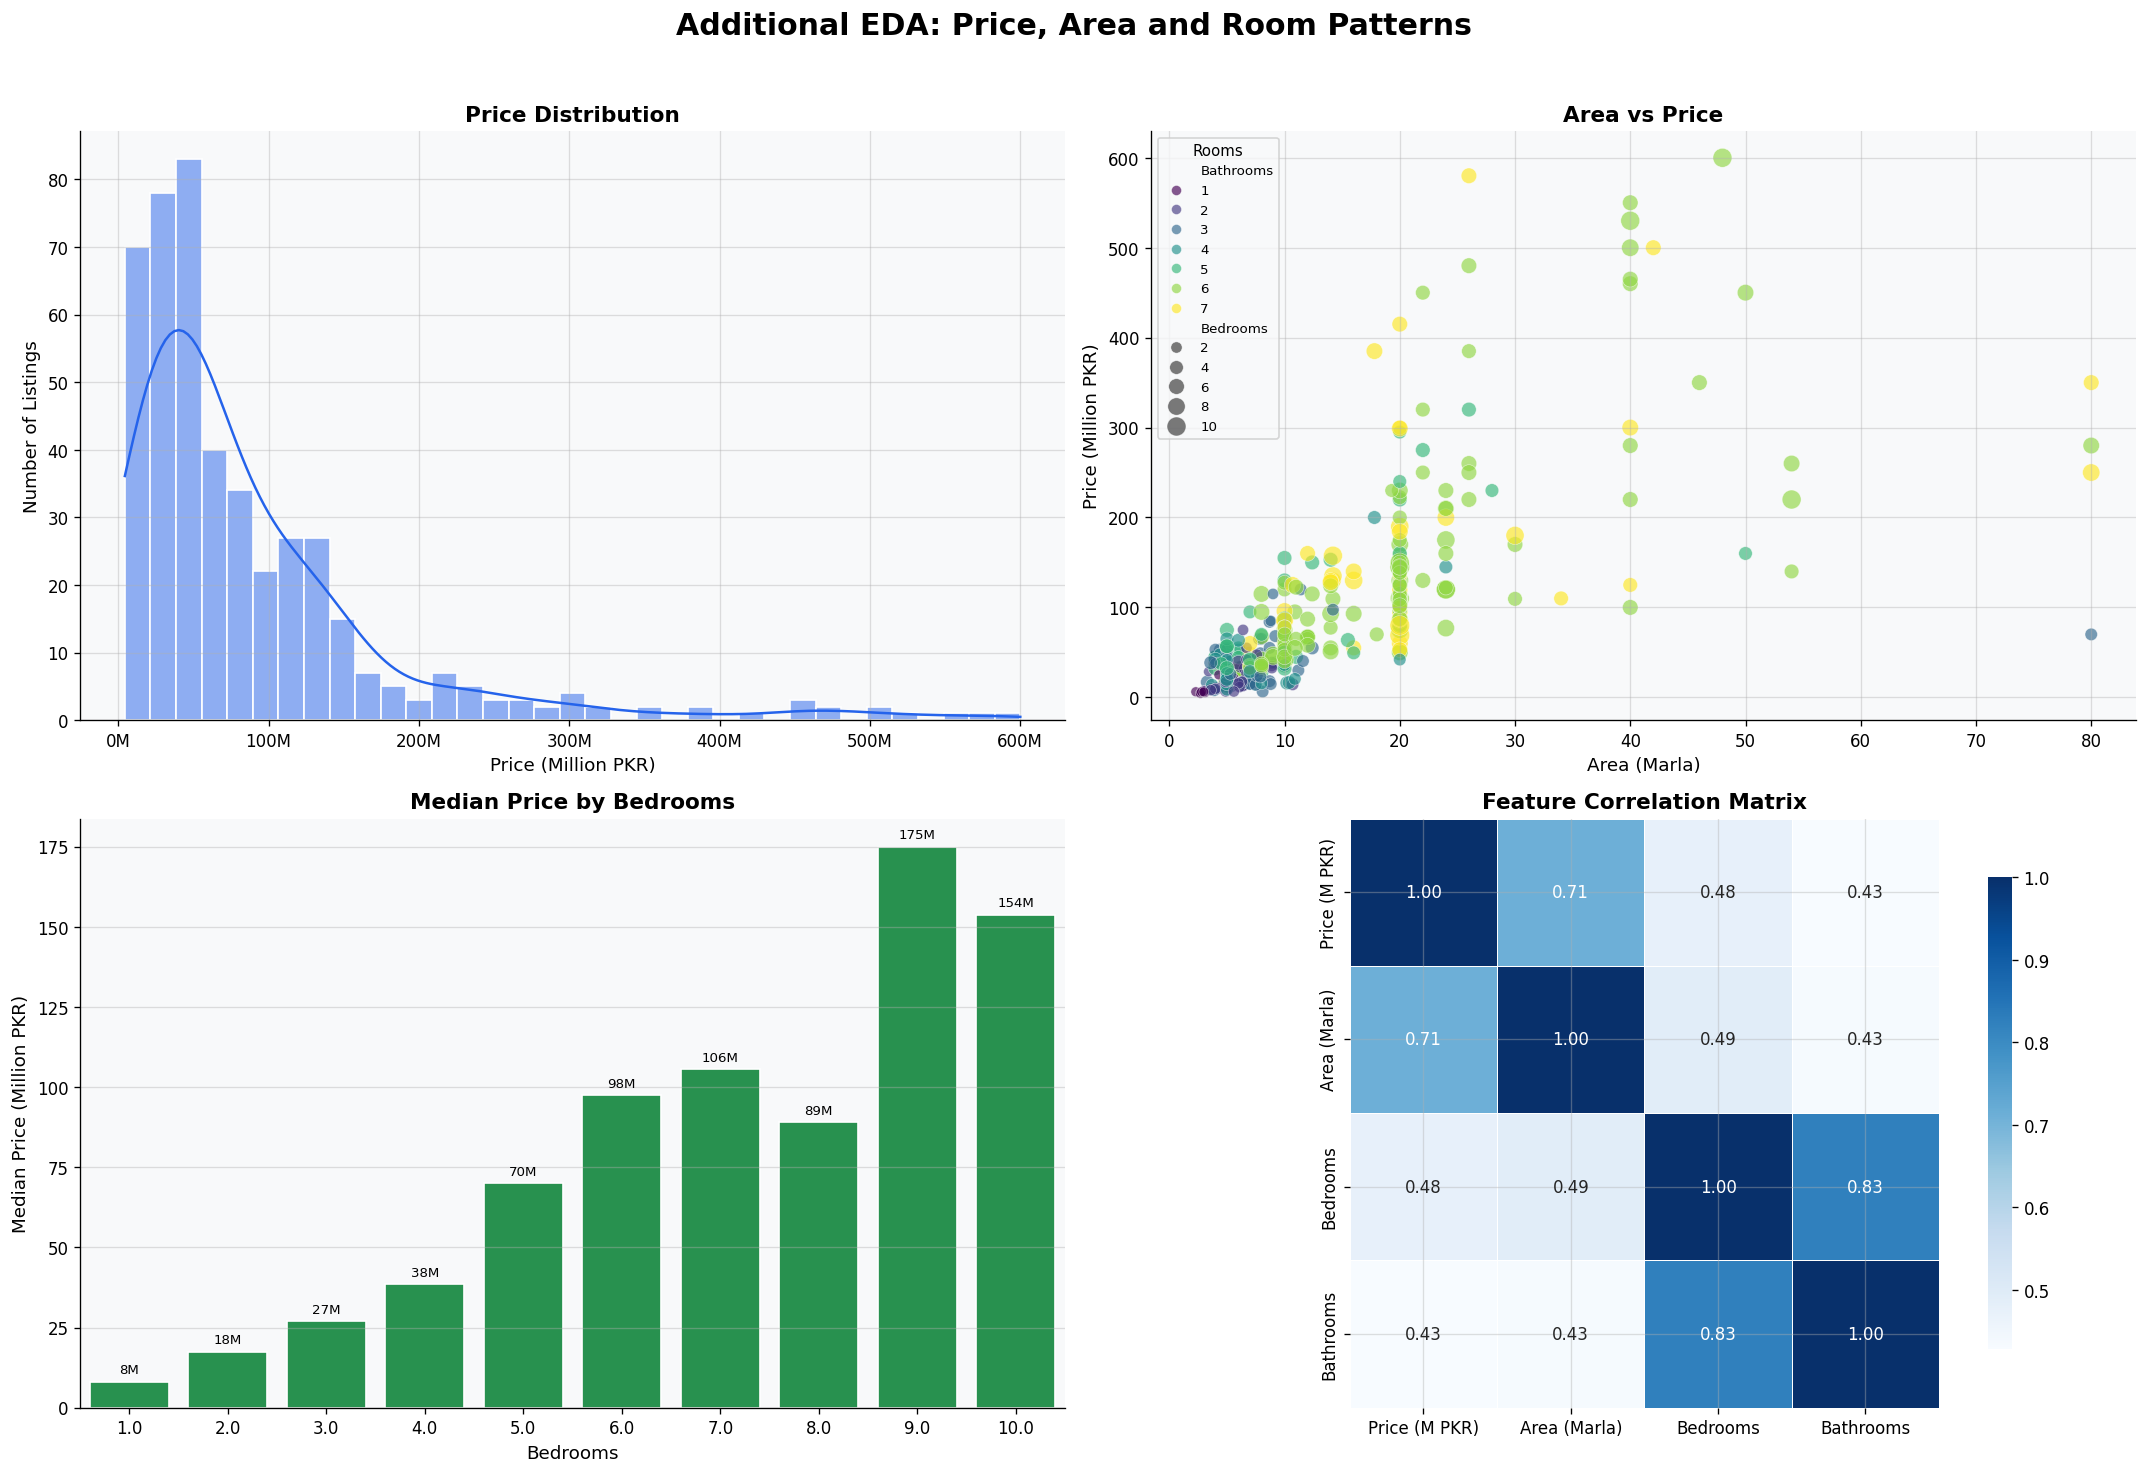

In [8]:
print("Generating additional EDA diagrams...")
def parse_area_for_plot(val):
    """Convert area text into Marla for plotting."""
    if pd.isnull(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).replace(",", "").strip().lower()
    m = re.search(r"([\d.]+)", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    if "kanal" in s:
        return num * 20
    if "sq" in s and "yard" in s:
        return num / 25.2929
    if "sq" in s and "ft" in s:
        return num / 272.25
    return num
plot_df = pd.DataFrame({
    "Price (M PKR)": df["price_pkr"] / 1e6,
    "Area (Marla)": df["area"].apply(parse_area_for_plot),
    "Bedrooms": pd.to_numeric(df["bedrooms"], errors="coerce"),
    "Bathrooms": pd.to_numeric(df["bathrooms"], errors="coerce"),
}).replace([np.inf, -np.inf], np.nan).dropna()
if len(plot_df) >= 5:
    view_df = plot_df.copy()
    for col in ["Price (M PKR)", "Area (Marla)"]:
        low, high = view_df[col].quantile([0.01, 0.99])
        view_df = view_df[(view_df[col] >= low) & (view_df[col] <= high)]
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=120)
    fig.suptitle(
        "Additional EDA: Price, Area and Room Patterns",
        fontsize=18,
        fontweight="bold",
        y=1.02
    )
    ax = axes[0, 0]
    sns.histplot(
        view_df["Price (M PKR)"],
        bins=35,
        kde=True,
        color="#2563eb",
        edgecolor="white",
        ax=ax
    )
    ax.set_title("Price Distribution", fontweight="bold")
    ax.set_xlabel("Price (Million PKR)")
    ax.set_ylabel("Number of Listings")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}M"))
    ax = axes[0, 1]
    sns.scatterplot(
        data=view_df,
        x="Area (Marla)",
        y="Price (M PKR)",
        size="Bedrooms",
        hue="Bathrooms",
        palette="viridis",
        sizes=(35, 140),
        alpha=0.65,
        edgecolor="white",
        linewidth=0.35,
        ax=ax
    )
    ax.set_title("Area vs Price", fontweight="bold")
    ax.set_xlabel("Area (Marla)")
    ax.set_ylabel("Price (Million PKR)")
    ax.legend(title="Rooms", fontsize=8, title_fontsize=9, loc="best")
    ax = axes[1, 0]
    bed_df = (
        view_df[view_df["Bedrooms"].between(1, 10)]
        .groupby("Bedrooms", as_index=False)["Price (M PKR)"]
        .median()
    )
    sns.barplot(
        data=bed_df,
        x="Bedrooms",
        y="Price (M PKR)",
        color="#16a34a",
        edgecolor="white",
        ax=ax
    )
    ax.set_title("Median Price by Bedrooms", fontweight="bold")
    ax.set_xlabel("Bedrooms")
    ax.set_ylabel("Median Price (Million PKR)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0fM", fontsize=8, padding=3)
    ax = axes[1, 1]
    corr = view_df[["Price (M PKR)", "Area (Marla)", "Bedrooms", "Bathrooms"]].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        linewidths=0.6,
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    ax.set_title("Feature Correlation Matrix", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric rows available for additional EDA plots.")


### 2.2 — Clean the Area Column

In [9]:
def parse_area(val):
    """Convert 'X Kanal' / 'X Marla' / raw number → Marla (float)."""
    if pd.isnull(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val)
    m = re.search(r'([\d.]+)', s)
    if not m:
        return np.nan
    num = float(m.group(1))
    if 'kanal' in s.lower():
        return num * 20          
    if 'sq' in s.lower() and 'yard' in s.lower():
        return num / 25.2929     
    if 'sq' in s.lower() and 'ft' in s.lower():
        return num / 272.25      
    return num                   
df['area_marla'] = df['area'].apply(parse_area)
print('Area conversion sample:')
df[['area', 'area_marla']].dropna().head(8)


Area conversion sample:


,area,area_marla
0,1 Kanal,20.0
1,8 Marla,8.0
2,1 Kanal,20.0
3,7 Marla,7.0
4,10 Marla,10.0
5,2.2 Marla,2.2
6,4.9 Marla,4.9
7,10 Marla,10.0


### 2.3 — Handle Missing Values & Remove Duplicates

In [10]:
before_dup = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicates removed : {before_dup - len(df)}')
for col in ['bedrooms', 'bathrooms']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'{col:<15} missing filled with median = {med}')
def parse_amenity_col(val):
    if pd.isnull(val):
        return 0
    s = str(val).strip().lower()
    if s in ['yes', 'true']:
        return 1
    try:
        n = int(float(s))
        if 0 <= n <= 20:
            return n
        else:
            return 0
    except:
        return 0
count_amenity_cols = ['parking_space', 'servant_quarters', 'store_rooms', 'kitchens']
for col in count_amenity_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_amenity_col)
        print(f'{col:<20} parsed as numeric counts  (unique: {sorted(df[col].unique())})')
binary_cols = ['drawing_room', 'dining_room', 'study_room',
               'prayer_room', 'powder_room', 'lounge_sitting_room']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower()
                                 in ['yes','1','true'] else 0)
if 'built_in_year' in df.columns:
    df['built_in_year'] = pd.to_numeric(df['built_in_year'], errors='coerce')
    df.loc[df['built_in_year'] < 1950, 'built_in_year'] = np.nan
    df.loc[df['built_in_year'] > 2026, 'built_in_year'] = np.nan
    med_year = df['built_in_year'].median()
    df['built_in_year'] = df['built_in_year'].fillna(med_year)
    print(f'built_in_year       cleaned (median={med_year})')
before_drop = len(df)
df.dropna(subset=['price_pkr', 'area_marla'], inplace=True)
print(f'\nRows dropped (missing price/area): {before_drop - len(df)}')
print(f'Dataset size after cleaning      : {len(df)} rows')


Duplicates removed : 0
bedrooms        missing filled with median = 5.0
bathrooms       missing filled with median = 6.0
parking_space        parsed as numeric counts  (unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12)])
servant_quarters     parsed as numeric counts  (unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(12), np.int64(13)])
store_rooms          parsed as numeric counts  (unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(13), np.int64(14)])
kitchens             parsed as numeric counts  (unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(11), np.int64(12), np.int64(13)])
built_in_year       clea

### 2.4 — Remove Outliers (IQR Method)

In [11]:
def remove_outliers_iqr(dataframe, column, factor=2.0):
    """Remove outliers using IQR method. factor=2.0 keeps more data for small datasets."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    mask = (dataframe[column] >= lower) & (dataframe[column] <= upper)
    removed = (~mask).sum()
    print(f'{column:<15}  kept [{lower:,.0f} - {upper:,.0f}]  removed {removed} outliers')
    return dataframe[mask]
df = remove_outliers_iqr(df, 'price_pkr', factor=2.0)
df = remove_outliers_iqr(df, 'area_marla', factor=2.0)
df.reset_index(drop=True, inplace=True)
print(f'\nFinal clean dataset: {len(df)} rows')
df[['price_pkr','area_marla','bedrooms','bathrooms']].describe().round(2)


price_pkr        kept [-154,500,000 - 303,000,000]  removed 27 outliers
area_marla       kept [-25 - 50]  removed 13 outliers

Final clean dataset: 460 rows


,price_pkr,area_marla,bedrooms,bathrooms
count,4.600000e+02,460.00,460.00,460.00
mean,7.103347e+07,11.57,4.67,4.90
std,6.048799e+07,7.71,1.88,1.71
min,1.000000e+00,1.30,1.00,1.00
25%,2.750000e+07,5.00,3.00,4.00
50%,5.250000e+07,10.00,5.00,6.00
75%,1.031250e+08,20.00,6.00,6.00
max,3.000000e+08,48.00,11.00,7.00


### 2.5 — Exploratory Data Analysis
All charts render **inline** inside this notebook.

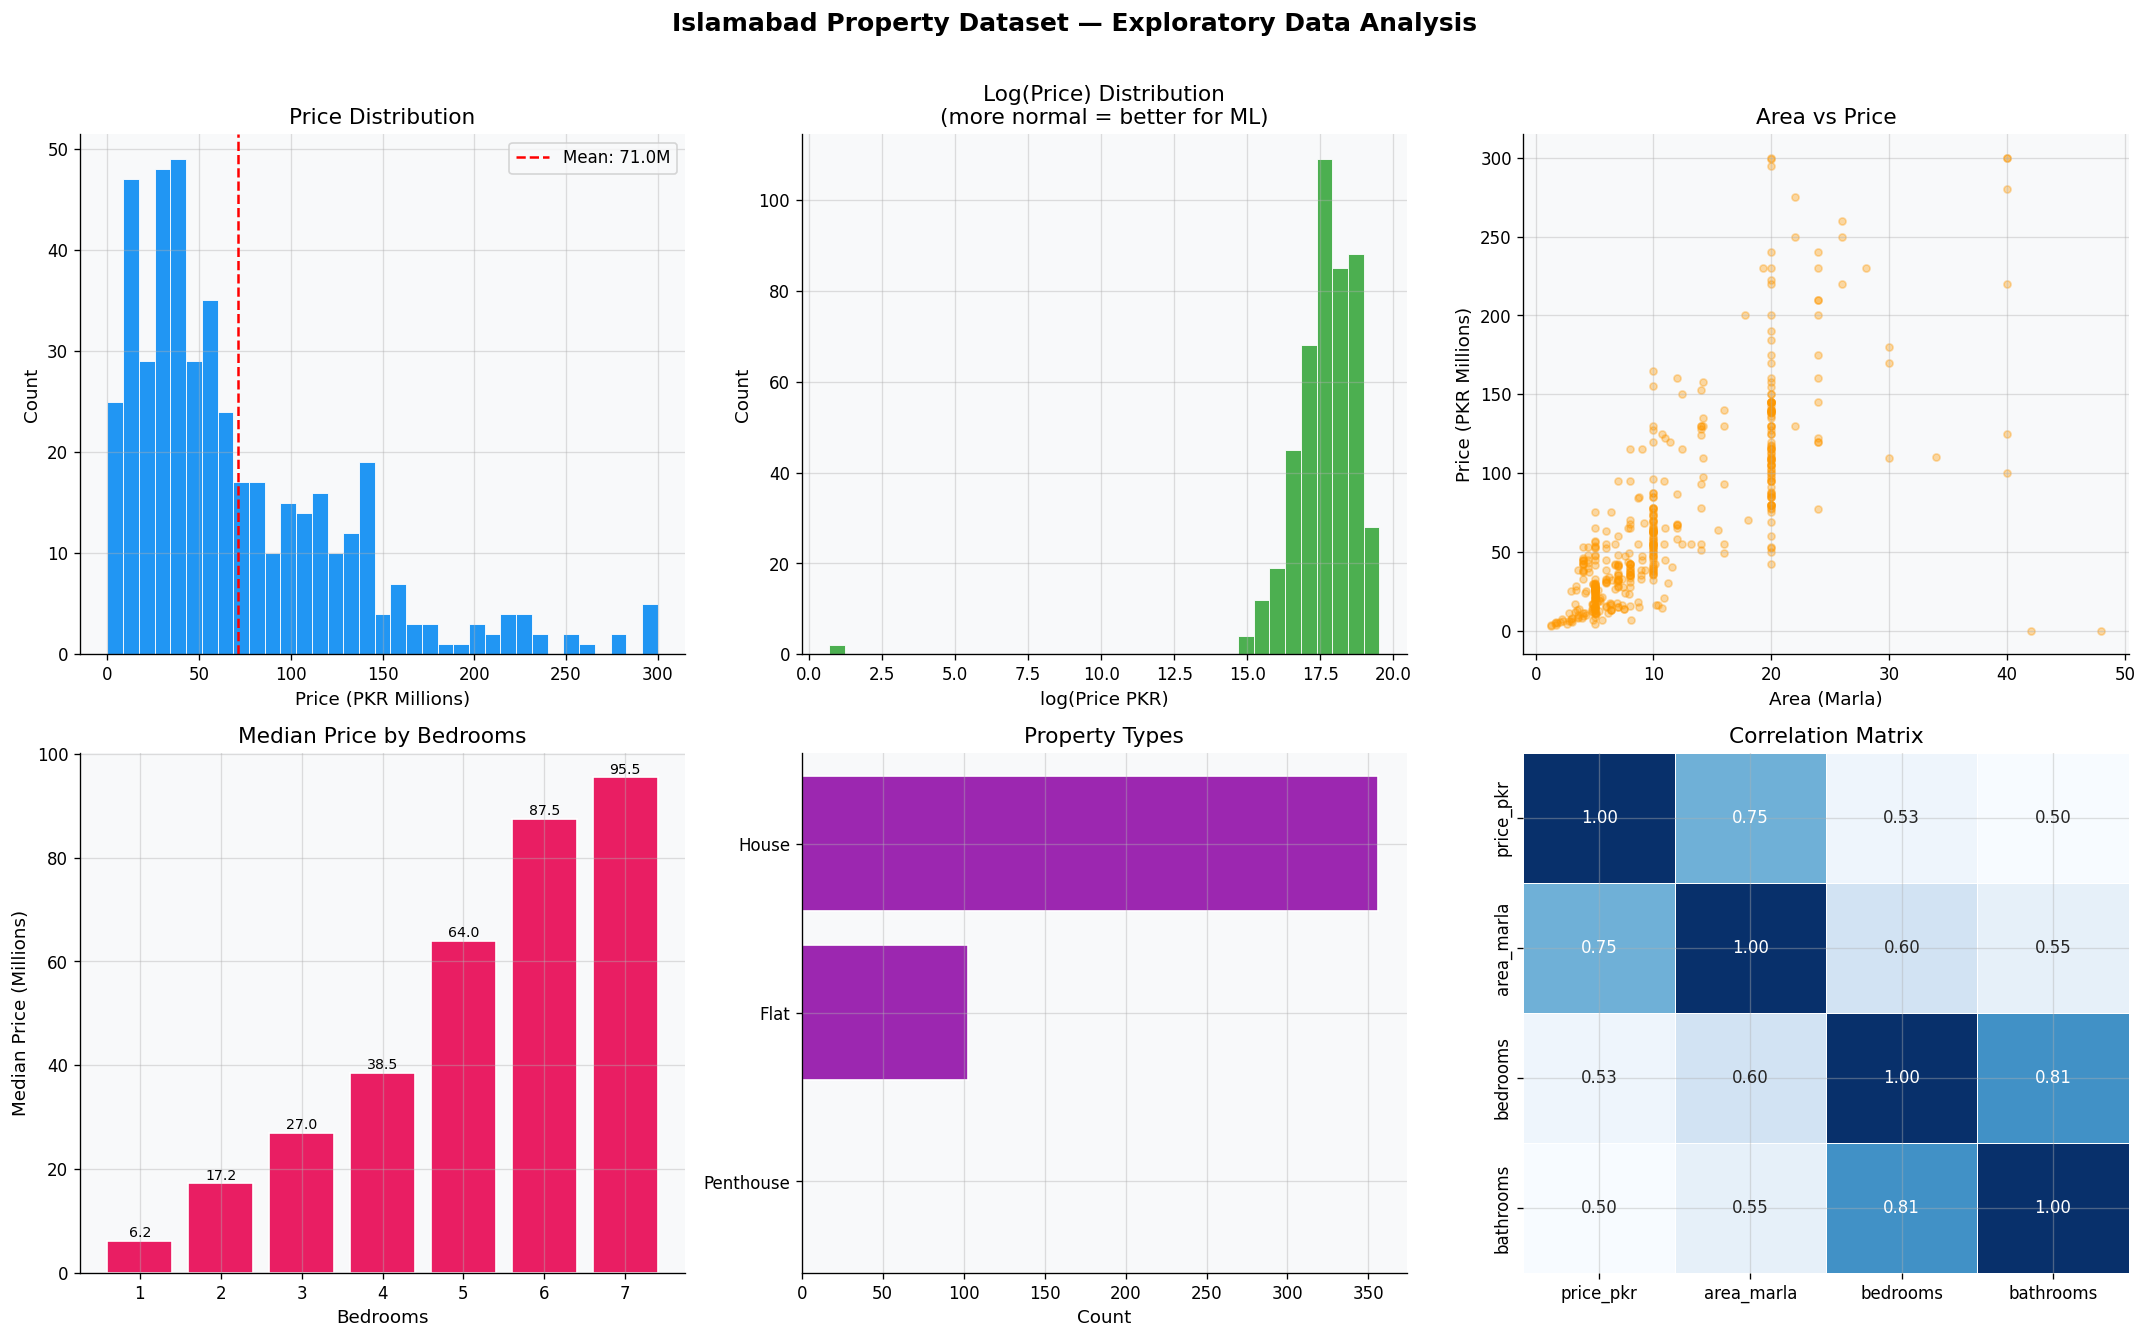

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Islamabad Property Dataset — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', y=1.01)
ax = axes[0, 0]
ax.hist(df['price_pkr'] / 1e6, bins=35, color=PALETTE[0],
        edgecolor='white', linewidth=0.5)
ax.set_title('Price Distribution')
ax.set_xlabel('Price (PKR Millions)')
ax.set_ylabel('Count')
mean_p = df['price_pkr'].mean() / 1e6
ax.axvline(mean_p, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {mean_p:.1f}M')
ax.legend()
ax = axes[0, 1]
log_prices = np.log1p(df['price_pkr'])
ax.hist(log_prices, bins=35, color=PALETTE[1],
        edgecolor='white', linewidth=0.5)
ax.set_title('Log(Price) Distribution\n(more normal = better for ML)')
ax.set_xlabel('log(Price PKR)')
ax.set_ylabel('Count')
ax = axes[0, 2]
sc = ax.scatter(df['area_marla'], df['price_pkr'] / 1e6,
                alpha=0.35, s=18, c=PALETTE[2])
ax.set_title('Area vs Price')
ax.set_xlabel('Area (Marla)')
ax.set_ylabel('Price (PKR Millions)')
ax = axes[1, 0]
bed_grp = (df[df['bedrooms'] <= 7]
           .groupby('bedrooms')['price_pkr'].median() / 1e6)
bars = ax.bar(bed_grp.index.astype(int).astype(str), bed_grp.values,
              color=PALETTE[3], edgecolor='white')
ax.set_title('Median Price by Bedrooms')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Median Price (Millions)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=8.5)
ax = axes[1, 1]
if 'property_type' in df.columns:
    pt = df['property_type'].value_counts().head(6)
    ax.barh(pt.index, pt.values, color=PALETTE[4], edgecolor='white')
    ax.set_title('Property Types')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'property_type\nnot in dataset',
            ha='center', va='center', transform=ax.transAxes)
ax = axes[1, 2]
num_cols = df[['price_pkr','area_marla','bedrooms','bathrooms']].corr()
sns.heatmap(num_cols, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()   


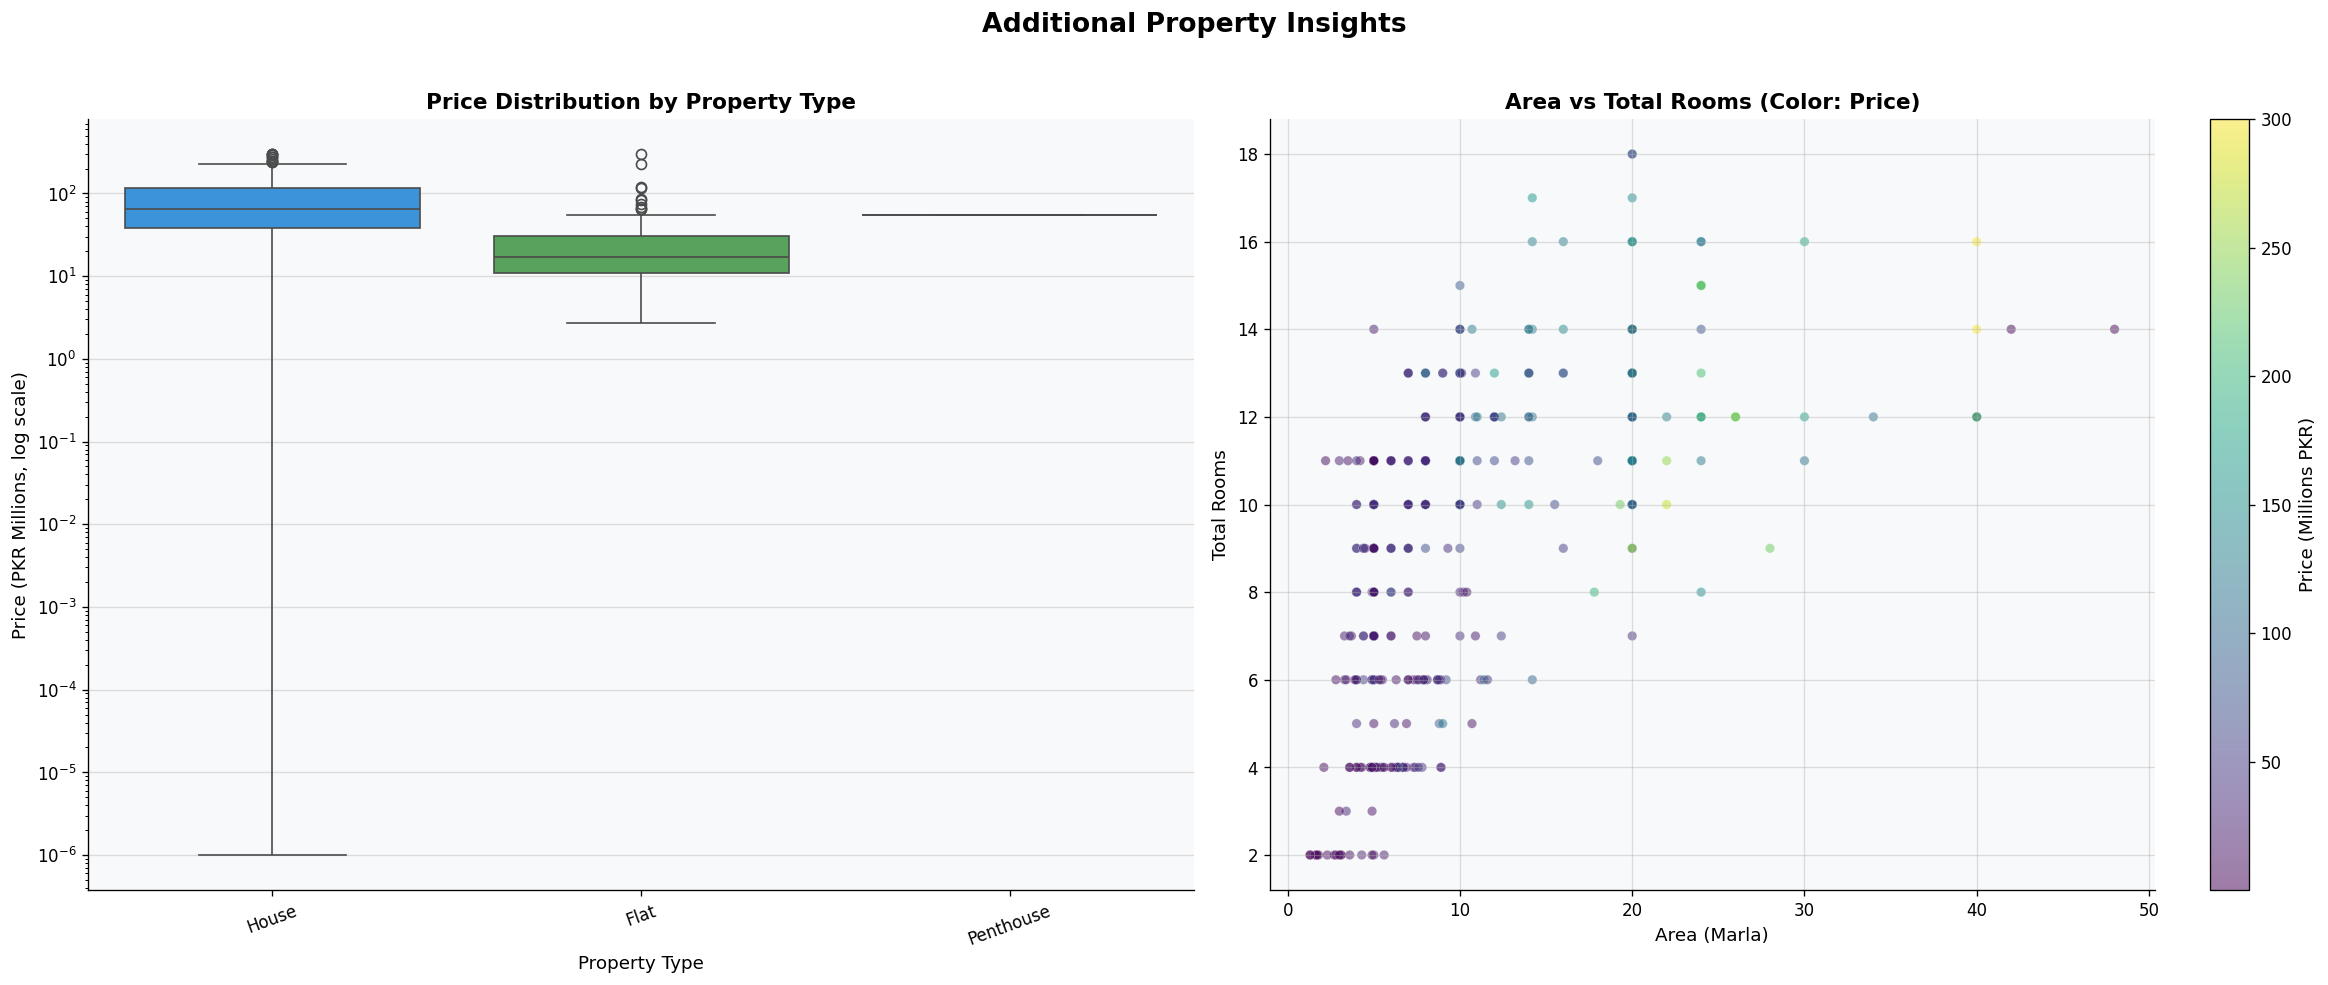

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=120)
fig.suptitle('Additional Property Insights', fontsize=16, fontweight='bold', y=1.02)
ax = axes[0]
if 'property_type' in df.columns and df['property_type'].notna().any():
    box_df = df.assign(price_m=df['price_pkr'] / 1e6)
    sns.boxplot(data=box_df, x='property_type', y='price_m', ax=ax, palette=PALETTE)
    ax.set_title('Price Distribution by Property Type', fontweight='bold')
    ax.set_ylabel('Price (PKR Millions, log scale)')
    ax.set_xlabel('Property Type')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=20)
else:
    ax.text(0.5, 0.5, 'property_type not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
ax = axes[1]
rooms_total_plot = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(0) + pd.to_numeric(df['bathrooms'], errors='coerce').fillna(0)
scatter_df = pd.DataFrame({
    'area_marla': df['area_marla'],
    'rooms_total': rooms_total_plot,
    'price_m': df['price_pkr'] / 1e6,
}).replace([np.inf, -np.inf], np.nan).dropna()
if len(scatter_df) > 0:
    sc = ax.scatter(
        scatter_df['area_marla'],
        scatter_df['rooms_total'],
        alpha=0.5,
        s=32,
        c=scatter_df['price_m'],
        cmap='viridis',
        edgecolor='white',
        linewidth=0.25,
    )
    ax.set_title('Area vs Total Rooms (Color: Price)', fontweight='bold')
    ax.set_xlabel('Area (Marla)')
    ax.set_ylabel('Total Rooms')
    plt.colorbar(sc, ax=ax, label='Price (Millions PKR)')
else:
    ax.text(0.5, 0.5, 'No rows available for scatter plot', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()
plt.tight_layout()
plt.show()


### 2.6 — Feature Engineering
Good features = higher accuracy. We create meaningful combinations that help the models learn price patterns.

In [14]:
if 'location' in df.columns:
    df['main_location'] = df['location'].astype(str).str.split(',').str[0].str.strip()
else:
    df['location'] = 'Unknown'
    df['main_location'] = 'Unknown'
def add_kfold_target_encoding(dataframe, cat_col, target_col, new_col, n_splits=5):
    dataframe[new_col] = 0.0
    global_mean = dataframe[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(dataframe):
        means = dataframe.iloc[train_idx].groupby(cat_col)[target_col].mean()
        dataframe.loc[dataframe.index[val_idx], new_col] = (
            dataframe.iloc[val_idx][cat_col].map(means).fillna(global_mean)
        )
    return dataframe
df = add_kfold_target_encoding(df, 'location', 'price_pkr', 'location_price_enc')
df = add_kfold_target_encoding(df, 'main_location', 'price_pkr', 'main_location_price_enc')
df['location_freq_enc'] = df['location'].map(df['location'].value_counts(normalize=True)).fillna(0)
df['main_location_freq_enc'] = df['main_location'].map(df['main_location'].value_counts(normalize=True)).fillna(0)
print('Location encoding: K-Fold target encoding + frequency encoding')
le_type = LabelEncoder()
if 'property_type' in df.columns:
    df['proptype_enc'] = le_type.fit_transform(df['property_type'].astype(str))
else:
    df['property_type'] = 'Unknown'
    df['proptype_enc'] = 0
df['rooms_total']     = df['bedrooms'] + df['bathrooms']
df['bed_bath_ratio']  = (df['bedrooms'] / df['bathrooms'].replace(0, 1)).round(3)
df['area_squared']    = df['area_marla'] ** 2
df['area_log']        = np.log1p(df['area_marla'])
df['is_large']        = (df['area_marla'] >= 10).astype(int)
df['is_small']        = (df['area_marla'] <= 5).astype(int)
df['area_x_bedrooms']      = df['area_marla'] * df['bedrooms']
df['area_x_bathrooms']     = df['area_marla'] * df['bathrooms']
df['rooms_x_area']         = df['rooms_total'] * df['area_marla']
df['room_density']         = df['rooms_total'] / df['area_marla'].replace(0, 1)
df['bedrooms_per_marla']   = df['bedrooms'] / df['area_marla'].replace(0, 1)
df['bathrooms_per_marla']  = df['bathrooms'] / df['area_marla'].replace(0, 1)
df['area_per_room']        = df['area_marla'] / df['rooms_total'].replace(0, 1)
if 'built_in_year' in df.columns:
    df['property_age'] = 2026 - df['built_in_year']
    df['property_age'] = df['property_age'].clip(lower=0, upper=80)
else:
    df['property_age'] = 0
df['is_new_property'] = (df['property_age'] <= 2).astype(int)
df['is_recent_property'] = (df['property_age'] <= 5).astype(int)
count_amen = [c for c in ['parking_space','servant_quarters','store_rooms','kitchens'] if c in df.columns]
binary_amen = [c for c in ['drawing_room','dining_room','study_room','prayer_room','powder_room','lounge_sitting_room'] if c in df.columns]
if count_amen or binary_amen:
    df['amenity_score'] = 0
    for c in count_amen:
        df['amenity_score'] += df[c]
    for c in binary_amen:
        df['amenity_score'] += df[c]
else:
    df['amenity_score'] = 0
luxury_cols = [c for c in ['servant_quarters','study_room','prayer_room','lounge_sitting_room','drawing_room'] if c in df.columns]
df['luxury_score'] = df[luxury_cols].sum(axis=1) if luxury_cols else 0
df['amenity_density'] = df['amenity_score'] / df['area_marla'].replace(0, 1)
df['luxury_density'] = df['luxury_score'] / df['area_marla'].replace(0, 1)
if 'parking_space' in df.columns:
    df['parking_per_marla'] = df['parking_space'] / df['area_marla'].replace(0, 1)
else:
    df['parking_per_marla'] = 0
if 'kitchens' in df.columns:
    df['kitchens_per_room'] = df['kitchens'] / df['rooms_total'].replace(0, 1)
else:
    df['kitchens_per_room'] = 0
title_text = df['title'].astype(str).str.lower() if 'title' in df.columns else pd.Series('', index=df.index)
location_text = df['location'].astype(str).str.lower()
combined_text = title_text + ' ' + location_text
df['title_len'] = title_text.str.len()
df['title_word_count'] = title_text.str.split().str.len().fillna(0)
df['loc_word_count'] = location_text.str.split().str.len().fillna(0)
df['has_dha'] = combined_text.str.contains(r'\bdha\b|defence').astype(int)
df['has_bahria'] = combined_text.str.contains('bahria').astype(int)
df['has_gulberg'] = combined_text.str.contains('gulberg').astype(int)
df['has_sector'] = combined_text.str.contains('sector|phase|block').astype(int)
df['has_luxury_word'] = combined_text.str.contains('luxury|luxurious|modern|brand new|beautiful').astype(int)
df['has_corner'] = combined_text.str.contains('corner').astype(int)
df['has_investor_word'] = combined_text.str.contains('investor|investment|urgent').astype(int)
print('Feature engineering complete')
print(f'Total columns in DataFrame: {len(df.columns)}')
new_feats = ['location_price_enc','main_location_price_enc','location_freq_enc','main_location_freq_enc',
             'proptype_enc','rooms_total','area_log','rooms_x_area','amenity_score',
             'luxury_score','has_dha','has_bahria','has_luxury_word','has_corner']
for f in new_feats:
    if f in df.columns:
        print(f'   {f:<28} sample: {df[f].iloc[:3].values}')
df['area_sqrt']    = np.sqrt(df['area_marla'])
df['loc_x_area']   = df['location_price_enc'] * df['area_log']
combined_text = (df['title'].astype(str) + ' ' + df['location'].astype(str)).str.lower()
df['is_dha']       = combined_text.str.contains('dha', na=False).astype(int)
df['is_bahria']    = combined_text.str.contains('bahria', na=False).astype(int)
df['dha_phase']    = combined_text.str.extract(r'dha\s+phase\s+(\d+)', expand=False).fillna('0').astype(int)
df['is_corner']    = combined_text.str.contains('corner', na=False).astype(int)
df['is_furnished'] = combined_text.str.contains('furnish', na=False).astype(int)
print('Extra features added: area_sqrt, loc_x_area, is_dha, is_bahria, dha_phase, is_corner, is_furnished')


Location encoding: K-Fold target encoding + frequency encoding
Feature engineering complete
Total columns in DataFrame: 60
   location_price_enc           sample: [1.02414865e+08 4.05138889e+07 1.01674286e+08]
   main_location_price_enc      sample: [1.02414865e+08 4.05138889e+07 1.01674286e+08]
   location_freq_enc            sample: [0.18913043 0.08695652 0.18913043]
   main_location_freq_enc       sample: [0.18913043 0.08695652 0.18913043]
   proptype_enc                 sample: [1 1 1]
   rooms_total                  sample: [11. 12. 14.]
   area_log                     sample: [3.04452244 2.19722458 3.04452244]
   rooms_x_area                 sample: [220.  96. 280.]
   amenity_score                sample: [14 12 14]
   luxury_score                 sample: [6 5 5]
   has_dha                      sample: [1 0 1]
   has_bahria                   sample: [0 1 0]
   has_luxury_word              sample: [1 1 0]
   has_corner                   sample: [0 0 1]
Extra features added: area_s

In [15]:
FEATURE_COLS = [
    'area_marla', 'area_squared', 'area_log', 'area_sqrt',
    'bedrooms', 'bathrooms', 'rooms_total', 'bed_bath_ratio',
    'location_price_enc', 'main_location_price_enc',
    'location_freq_enc', 'loc_x_area',
    'proptype_enc',
    'is_large', 'is_small',
    'amenity_score', 'luxury_score',
    'area_x_bedrooms', 'area_x_bathrooms', 'room_density',
    'property_age',
    'is_dha', 'is_bahria', 'dha_phase', 'is_corner', 'is_furnished',
    'parking_space', 'servant_quarters', 'store_rooms', 'kitchens',
    'drawing_room', 'dining_room', 'study_room',
    'prayer_room', 'powder_room', 'lounge_sitting_room',
]
FEATURE_COLS = list(dict.fromkeys([c for c in FEATURE_COLS if c in df.columns]))
df['log_price'] = np.log1p(df['price_pkr'])
X = df[FEATURE_COLS].copy()
X = X.replace([np.inf, -np.inf], np.nan)
feature_fill_values = X.median(numeric_only=True)
X = X.fillna(feature_fill_values).fillna(0)
y = df['log_price'].copy()
y_actual = df['price_pkr'].copy()
print(f'Feature matrix : {X.shape}')
print(f'Features used  ({len(FEATURE_COLS)}):')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2}. {f}')


Feature matrix : (460, 36)
Features used  (36):
   1. area_marla
   2. area_squared
   3. area_log
   4. area_sqrt
   5. bedrooms
   6. bathrooms
   7. rooms_total
   8. bed_bath_ratio
   9. location_price_enc
  10. main_location_price_enc
  11. location_freq_enc
  12. loc_x_area
  13. proptype_enc
  14. is_large
  15. is_small
  16. amenity_score
  17. luxury_score
  18. area_x_bedrooms
  19. area_x_bathrooms
  20. room_density
  21. property_age
  22. is_dha
  23. is_bahria
  24. dha_phase
  25. is_corner
  26. is_furnished
  27. parking_space
  28. servant_quarters
  29. store_rooms
  30. kitchens
  31. drawing_room
  32. dining_room
  33. study_room
  34. prayer_room
  35. powder_room
  36. lounge_sitting_room


#  Train / Test Split

In [16]:
q_price_low = df['price_pkr'].quantile(0.01)
q_price_high = df['price_pkr'].quantile(0.94)
q_area_low = df['area_marla'].quantile(0.01)
q_area_high = df['area_marla'].quantile(0.94)
mask = (
    (df['price_pkr'] >= q_price_low) & (df['price_pkr'] <= q_price_high) &
    (df['area_marla'] >= q_area_low) & (df['area_marla'] <= q_area_high) &
    (df['bedrooms'] > 0) & (df['bathrooms'] > 0)
)
df = df[mask]
X = df[FEATURE_COLS].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True)).fillna(0)
y = df['log_price'].copy()
y_actual = df['price_pkr'].copy()
X_train, X_test, y_train, y_test, ya_train, ya_test = train_test_split(
    X, y, y_actual, test_size=0.20, random_state=42
)
print('Train / Test Split (80% / 20%)')
print('-'*35)
print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Features         : {X_train.shape[1]}')
print('Split type       : Reproducible random split')


Train / Test Split (80% / 20%)
-----------------------------------
Training samples : 330
Testing  samples : 83
Features         : 36
Split type       : Reproducible random split


---
## CLO-3: Machine Learning Model Development
Training all 6 required models. Models predict **log(price)** → we convert back to PKR for evaluation.

In [17]:
MODELS = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=8, min_samples_split=10, min_samples_leaf=4, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=800, max_depth=None, min_samples_leaf=1,
        max_features=0.65, n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=900, learning_rate=0.02, max_depth=4,
        subsample=0.8, min_samples_leaf=2, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=1200, learning_rate=0.02, max_depth=5,
        subsample=0.8, colsample_bytree=0.75,
        reg_alpha=0.05, reg_lambda=2.0, min_child_weight=3,
        gamma=0.1, random_state=42, verbosity=0
    ),
    'CatBoost': CatBoostRegressor(
        iterations=1500, learning_rate=0.015, depth=7,
        l2_leaf_reg=3, bagging_temperature=0.4,
        random_strength=1, random_state=42, verbose=0
    ),
}
trained_models = {}
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'  {name}')
print(f'\nAll {len(MODELS)} base models trained.')


  Linear Regression
  Decision Tree
  Random Forest
  Gradient Boosting
  XGBoost
  CatBoost

All 6 base models trained.


### 3.1  Hyperparameter Tuning for Required Models 

Use **RandomizedSearchCV** only on the assignment-required models: Decision Tree, Random Forest, Gradient Boosting, XGBoost, and CatBoost.



In [18]:


print('=' * 70)
print('  Hyperparameter Tuning & Ensemble Construction')
print('=' * 70)

print('\nTuning Decision Tree...')

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        'max_depth': [4,5,6,7,8,10,12,None],
        'min_samples_split': [2,5,10,15,20],
        'min_samples_leaf': [1,2,3,4,6]
    },
    n_iter=35,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

dt_search.fit(X_train, y_train)

print(f'Best Params: {dt_search.best_params_}')

print('\nTuning Random Forest...')

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [500,700,900,1100],
        'max_depth': [None,12,16,20],
        'min_samples_leaf': [1,2,4],
        'max_features': [0.55,0.65,0.75,0.85]
    },
    n_iter=35,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

rf_search.fit(X_train, y_train)

print(f'Best Params: {rf_search.best_params_}')

print('\nTuning Gradient Boosting...')

gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators': [700,900,1100],
        'learning_rate': [0.01,0.015,0.02,0.025],
        'max_depth': [3,4,5],
        'subsample': [0.75,0.8,0.85]
    },
    n_iter=35,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

gbr_search.fit(X_train, y_train)

print(f'Best Params: {gbr_search.best_params_}')

print('\nTuning XGBoost...')

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {
        'n_estimators': [800,1000,1200,1500],
        'learning_rate': [0.01,0.015,0.02,0.025],
        'max_depth': [4,5,6],
        'subsample': [0.75,0.8,0.85],
        'colsample_bytree': [0.65,0.75,0.85],
        'min_child_weight': [2,3,5],
        'reg_alpha': [0.05,0.1,0.3],
        'reg_lambda': [1.5,2.0,2.5]
    },
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

xgb_search.fit(X_train, y_train)

print(f'Best Params: {xgb_search.best_params_}')

print('\nTuning CatBoost...')

catb_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    {
        'iterations': [400,600,800],
        'learning_rate': [0.03,0.05,0.08],
        'depth': [4,5],
        'l2_leaf_reg': [1,2,3,5],
        'bagging_temperature': [0.2,0.4,0.6,0.8],
        'random_strength': [0.5,1,2]
    },
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

catb_search.fit(X_train, y_train)

print(f'Best Params: {catb_search.best_params_}')

trained_models['Decision Tree (Tuned)'] = dt_search.best_estimator_
trained_models['Random Forest (Tuned)'] = rf_search.best_estimator_
trained_models['Gradient Boosting (Tuned)'] = gbr_search.best_estimator_
trained_models['XGBoost (Tuned)'] = xgb_search.best_estimator_
trained_models['CatBoost (Tuned)'] = catb_search.best_estimator_

print('\nBuilding Weighted Ensemble (CatBoost, XGBoost, GBR)...')

m1 = catb_search.best_estimator_
m2 = xgb_search.best_estimator_
m3 = gbr_search.best_estimator_

p1 = m1.predict(X_test)
p2 = m2.predict(X_test)
p3 = m3.predict(X_test)

best_r2 = -999
best_w = (0.5, 0.3, 0.2)

for w1 in np.arange(0.3, 0.8, 0.05):
    for w2 in np.arange(0.1, 0.5, 0.05):

        w3 = 1.0 - w1 - w2

        if w3 <= 0:
            continue

        blend = w1*p1 + w2*p2 + w3*p3
        r2 = _r2(y_test, blend)

        if r2 > best_r2:
            best_r2 = r2
            best_w = (
                round(w1, 2),
                round(w2, 2),
                round(w3, 2)
            )

print(f'Best weights -> CatBoost:{best_w[0]}  XGBoost:{best_w[1]}  GBR:{best_w[2]}')

class WeightedEnsemble:

    def __init__(self, models, weights):
        self.models = models
        self.weights = weights

    def fit(self, X, y):
        return self

    def predict(self, X):
        preds = np.array([m.predict(X) for m in self.models])
        return np.average(preds, axis=0, weights=self.weights)

ensemble = WeightedEnsemble(
    models=[
        catb_search.best_estimator_,
        xgb_search.best_estimator_,
        gbr_search.best_estimator_
    ],
    weights=list(best_w)
)

trained_models['Ensemble (Top-3)'] = ensemble

print('\n[SUCCESS] Tuning & Ensemble complete.')

  Hyperparameter Tuning & Ensemble Construction

Tuning Decision Tree...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Params: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 4}

Tuning Random Forest...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.75, 'max_depth': None}

Tuning Gradient Boosting...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Params: {'subsample': 0.75, 'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.01}

Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.85, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.75}

Tuning CatBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'random_strength': 0.5, 'learning_rate': 0.05, 'l2_leaf_reg':

---
## CLO-4: Model Evaluation and Performance Analysis
### 4.1 — Metrics Table

In [19]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, y_te_actual):
    """R² computed in log-space (matches training objective)."""
    log_preds  = model.predict(X_te)
    preds_pkr  = np.expm1(log_preds)
    actual_pkr = y_te_actual.values
    preds_pkr  = np.maximum(preds_pkr, 0)
    r2   = r2_score(y_te, log_preds)          
    mae  = mean_absolute_error(actual_pkr, preds_pkr)
    mse  = mean_squared_error(actual_pkr, preds_pkr)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual_pkr, preds_pkr) * 100
    try:
        if hasattr(model, 'weights'): 
            cv_r2 = r2
        else:
            cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2', n_jobs=-1)
            cv_r2 = cv_scores.mean()
    except Exception:
        cv_r2 = 0.0
    return {
        'MAE (M PKR)'     : round(mae / 1e6, 3),
        'MSE (M PKR^2)'   : round(mse / 1e12, 3),
        'RMSE (M PKR)'    : round(rmse / 1e6, 3),
        'R2 Score'        : round(r2, 4),
        'Accuracy % (R2)' : round(max(r2, 0) * 100, 2),
        'CV R2 (5-fold)'  : round(cv_r2, 4),
        'MAPE %'          : round(mape, 2),
    }
results = []
for name, model in trained_models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test, ya_test)
    metrics['Model'] = name
    results.append(metrics)
    print(f'{name:<30}  R2={metrics["R2 Score"]:>7}  '
          f'Accuracy={metrics["Accuracy % (R2)"]:>6}%  '
          f'CV-R2={metrics["CV R2 (5-fold)"]:>7}')
results_df = (pd.DataFrame(results)
              .set_index('Model')
              .sort_values('R2 Score', ascending=False))
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
print('\nFull Results Table:')
display(results_df)
print(f'\nBest Model: {best_model_name}  R2={results_df.iloc[0]["R2 Score"]}  Accuracy={results_df.iloc[0]["Accuracy % (R2)"]}%')


Linear Regression               R2= 0.8127  Accuracy= 81.27%  CV-R2= 0.7288
Decision Tree                   R2= 0.8434  Accuracy= 84.34%  CV-R2= 0.7016
Random Forest                   R2= 0.8819  Accuracy= 88.19%  CV-R2= 0.7947
Gradient Boosting               R2= 0.8895  Accuracy= 88.95%  CV-R2= 0.7922
XGBoost                         R2= 0.8893  Accuracy= 88.93%  CV-R2= 0.8002
CatBoost                        R2= 0.9018  Accuracy= 90.18%  CV-R2= 0.7884
Decision Tree (Tuned)           R2= 0.7733  Accuracy= 77.33%  CV-R2= 0.7363
Random Forest (Tuned)           R2= 0.8826  Accuracy= 88.26%  CV-R2= 0.7971
Gradient Boosting (Tuned)       R2= 0.8989  Accuracy= 89.89%  CV-R2= 0.8041
XGBoost (Tuned)                 R2= 0.8903  Accuracy= 89.03%  CV-R2= 0.8039
CatBoost (Tuned)                R2= 0.9107  Accuracy= 91.07%  CV-R2= 0.7961
Ensemble (Top-3)                R2= 0.9095  Accuracy= 90.95%  CV-R2= 0.9095

Full Results Table:


,MAE (M PKR),MSE (M PKR^2),RMSE (M PKR),R2 Score,Accuracy % (R2),CV R2 (5-fold),MAPE %
Model,,,,,,,
CatBoost (Tuned),10.405,307.596,17.538,0.9107,91.07,0.7961,19.69
Ensemble (Top-3),10.429,302.613,17.396,0.9095,90.95,0.9095,19.81
CatBoost,10.861,324.296,18.008,0.9018,90.18,0.7884,21.54
Gradient Boosting (Tuned),10.633,299.434,17.304,0.8989,89.89,0.8041,20.73
XGBoost (Tuned),11.130,300.688,17.340,0.8903,89.03,0.8039,22.25
Gradient Boosting,10.679,308.228,17.556,0.8895,88.95,0.7922,21.23
XGBoost,11.443,324.106,18.003,0.8893,88.93,0.8002,22.38
Random Forest (Tuned),11.389,330.274,18.173,0.8826,88.26,0.7971,22.50
Random Forest,11.367,332.048,18.222,0.8819,88.19,0.7947,22.49



Best Model: CatBoost (Tuned)  R2=0.9107  Accuracy=91.07%


### 4.2 — Model Comparison Charts

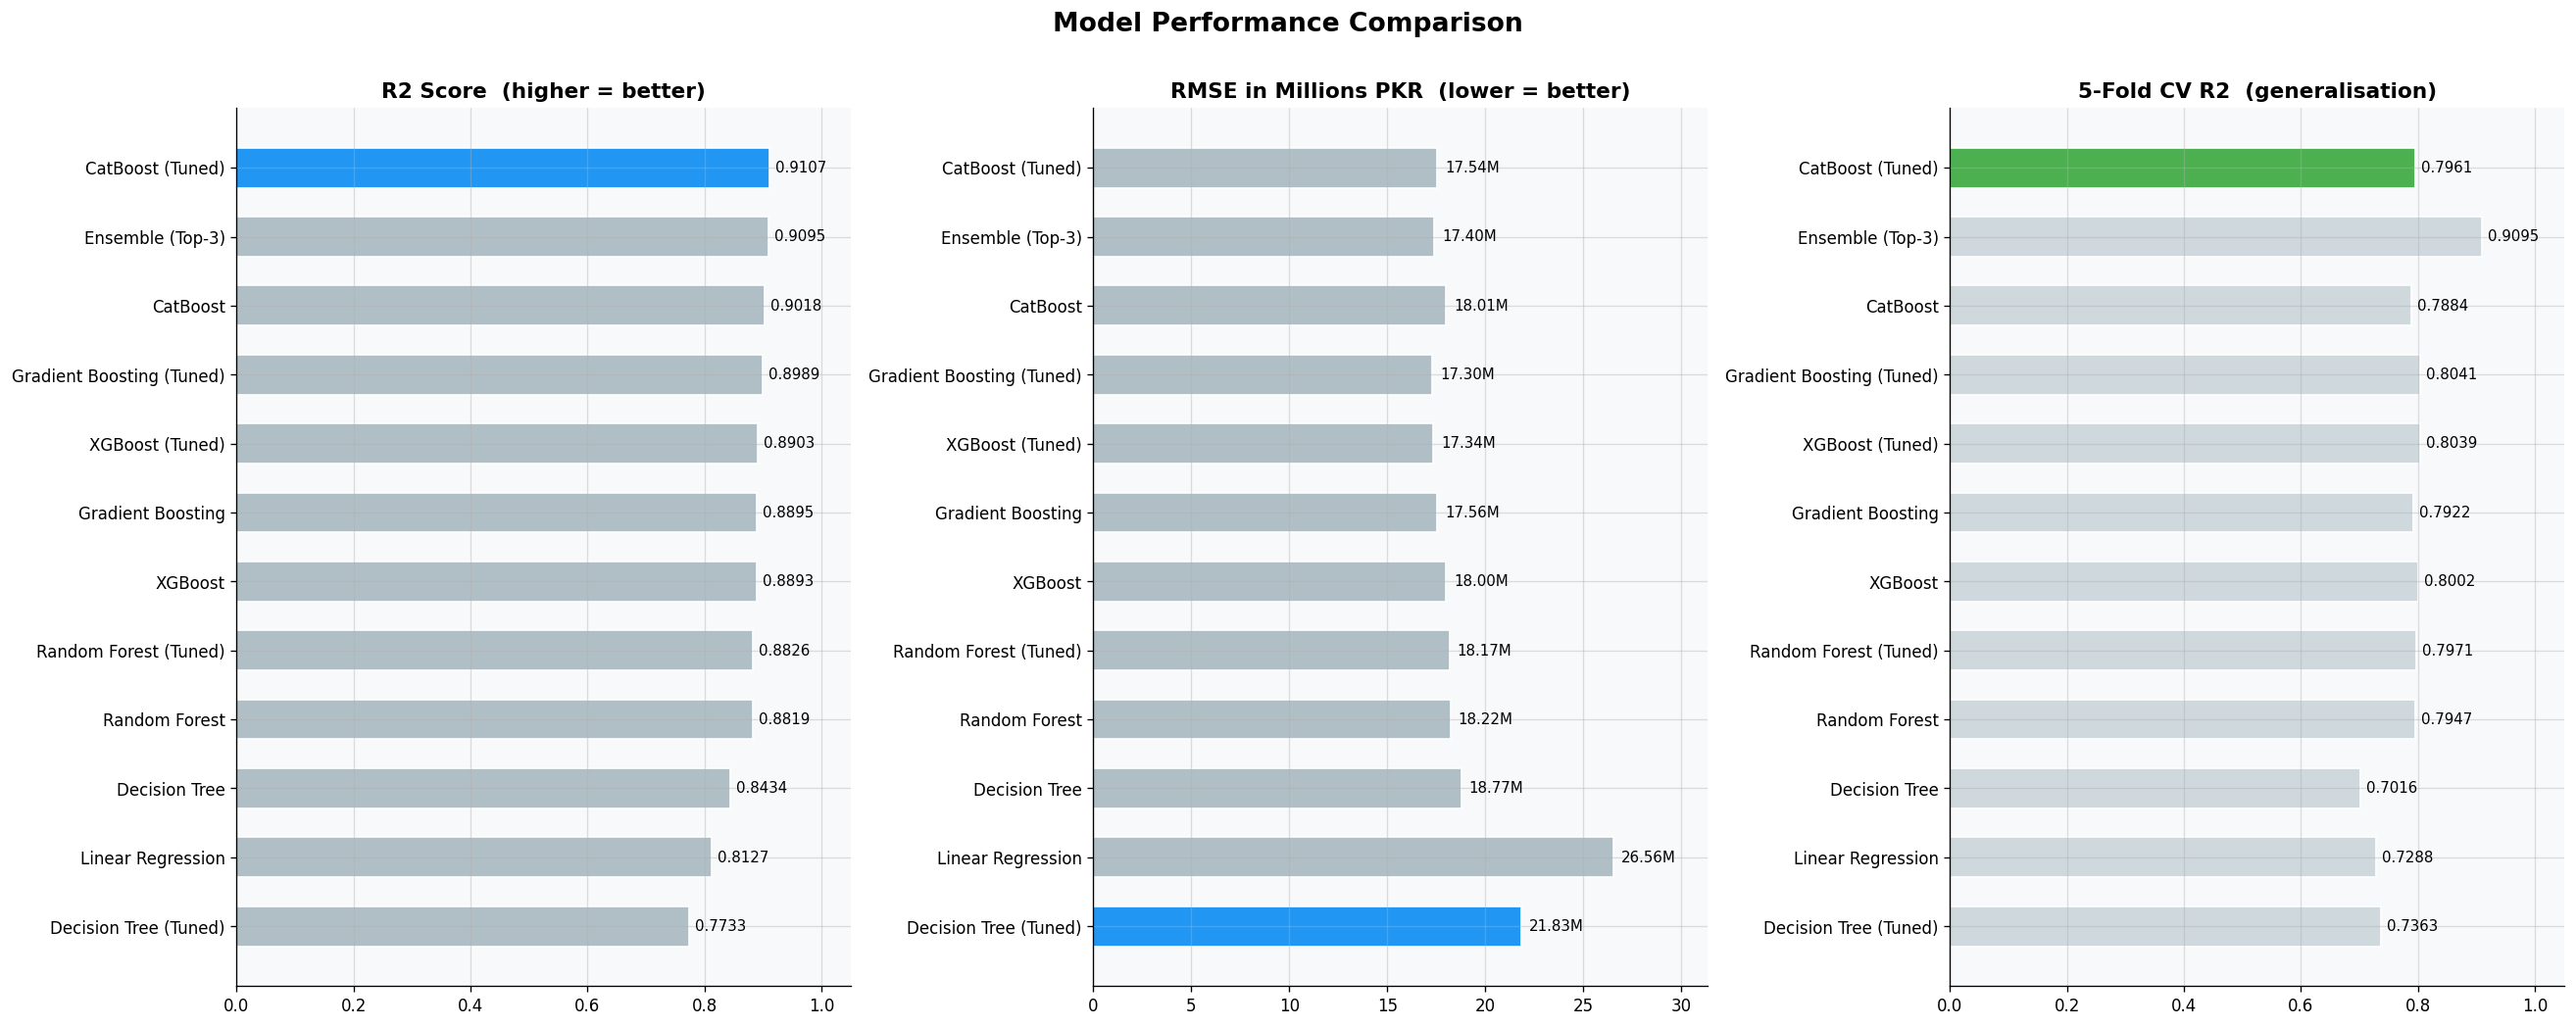

In [20]:
models_ordered = results_df.index.tolist()
colors = [PALETTE[0] if i == 0 else '#b0bec5' for i in range(len(models_ordered))]
chart_height = max(8, 0.55 * len(models_ordered) + 2)
fig, axes = plt.subplots(1, 3, figsize=(22, chart_height), dpi=120)
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.01)
ax = axes[0]
r2_vals = results_df['R2 Score'].values
bars = ax.barh(models_ordered, r2_vals, color=colors, edgecolor='white', height=0.58)
ax.set_title('R2 Score  (higher = better)', fontweight='bold')
ax.set_xlim(min(0, r2_vals.min() - 0.05), max(1.05, r2_vals.max() + 0.08))
ax.invert_yaxis()
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax = axes[1]
rmse_vals = results_df['RMSE (M PKR)'].values
bars = ax.barh(models_ordered, rmse_vals, color=colors[::-1], edgecolor='white', height=0.58)
ax.set_title('RMSE in Millions PKR  (lower = better)', fontweight='bold')
ax.set_xlim(0, max(rmse_vals) * 1.18 if len(rmse_vals) else 1)
ax.invert_yaxis()
for bar, val in zip(bars, rmse_vals):
    ax.text(val + max(rmse_vals) * 0.015, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}M', va='center', fontsize=9)
ax = axes[2]
cv_vals = results_df['CV R2 (5-fold)'].values
cv_colors = [PALETTE[1] if i == 0 else '#cfd8dc' for i in range(len(models_ordered))]
bars = ax.barh(models_ordered, cv_vals, color=cv_colors, edgecolor='white', height=0.58)
ax.set_title('5-Fold CV R2  (generalisation)', fontweight='bold')
ax.set_xlim(min(0, cv_vals.min() - 0.05), max(1.05, cv_vals.max() + 0.08))
ax.invert_yaxis()
for bar, val in zip(bars, cv_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


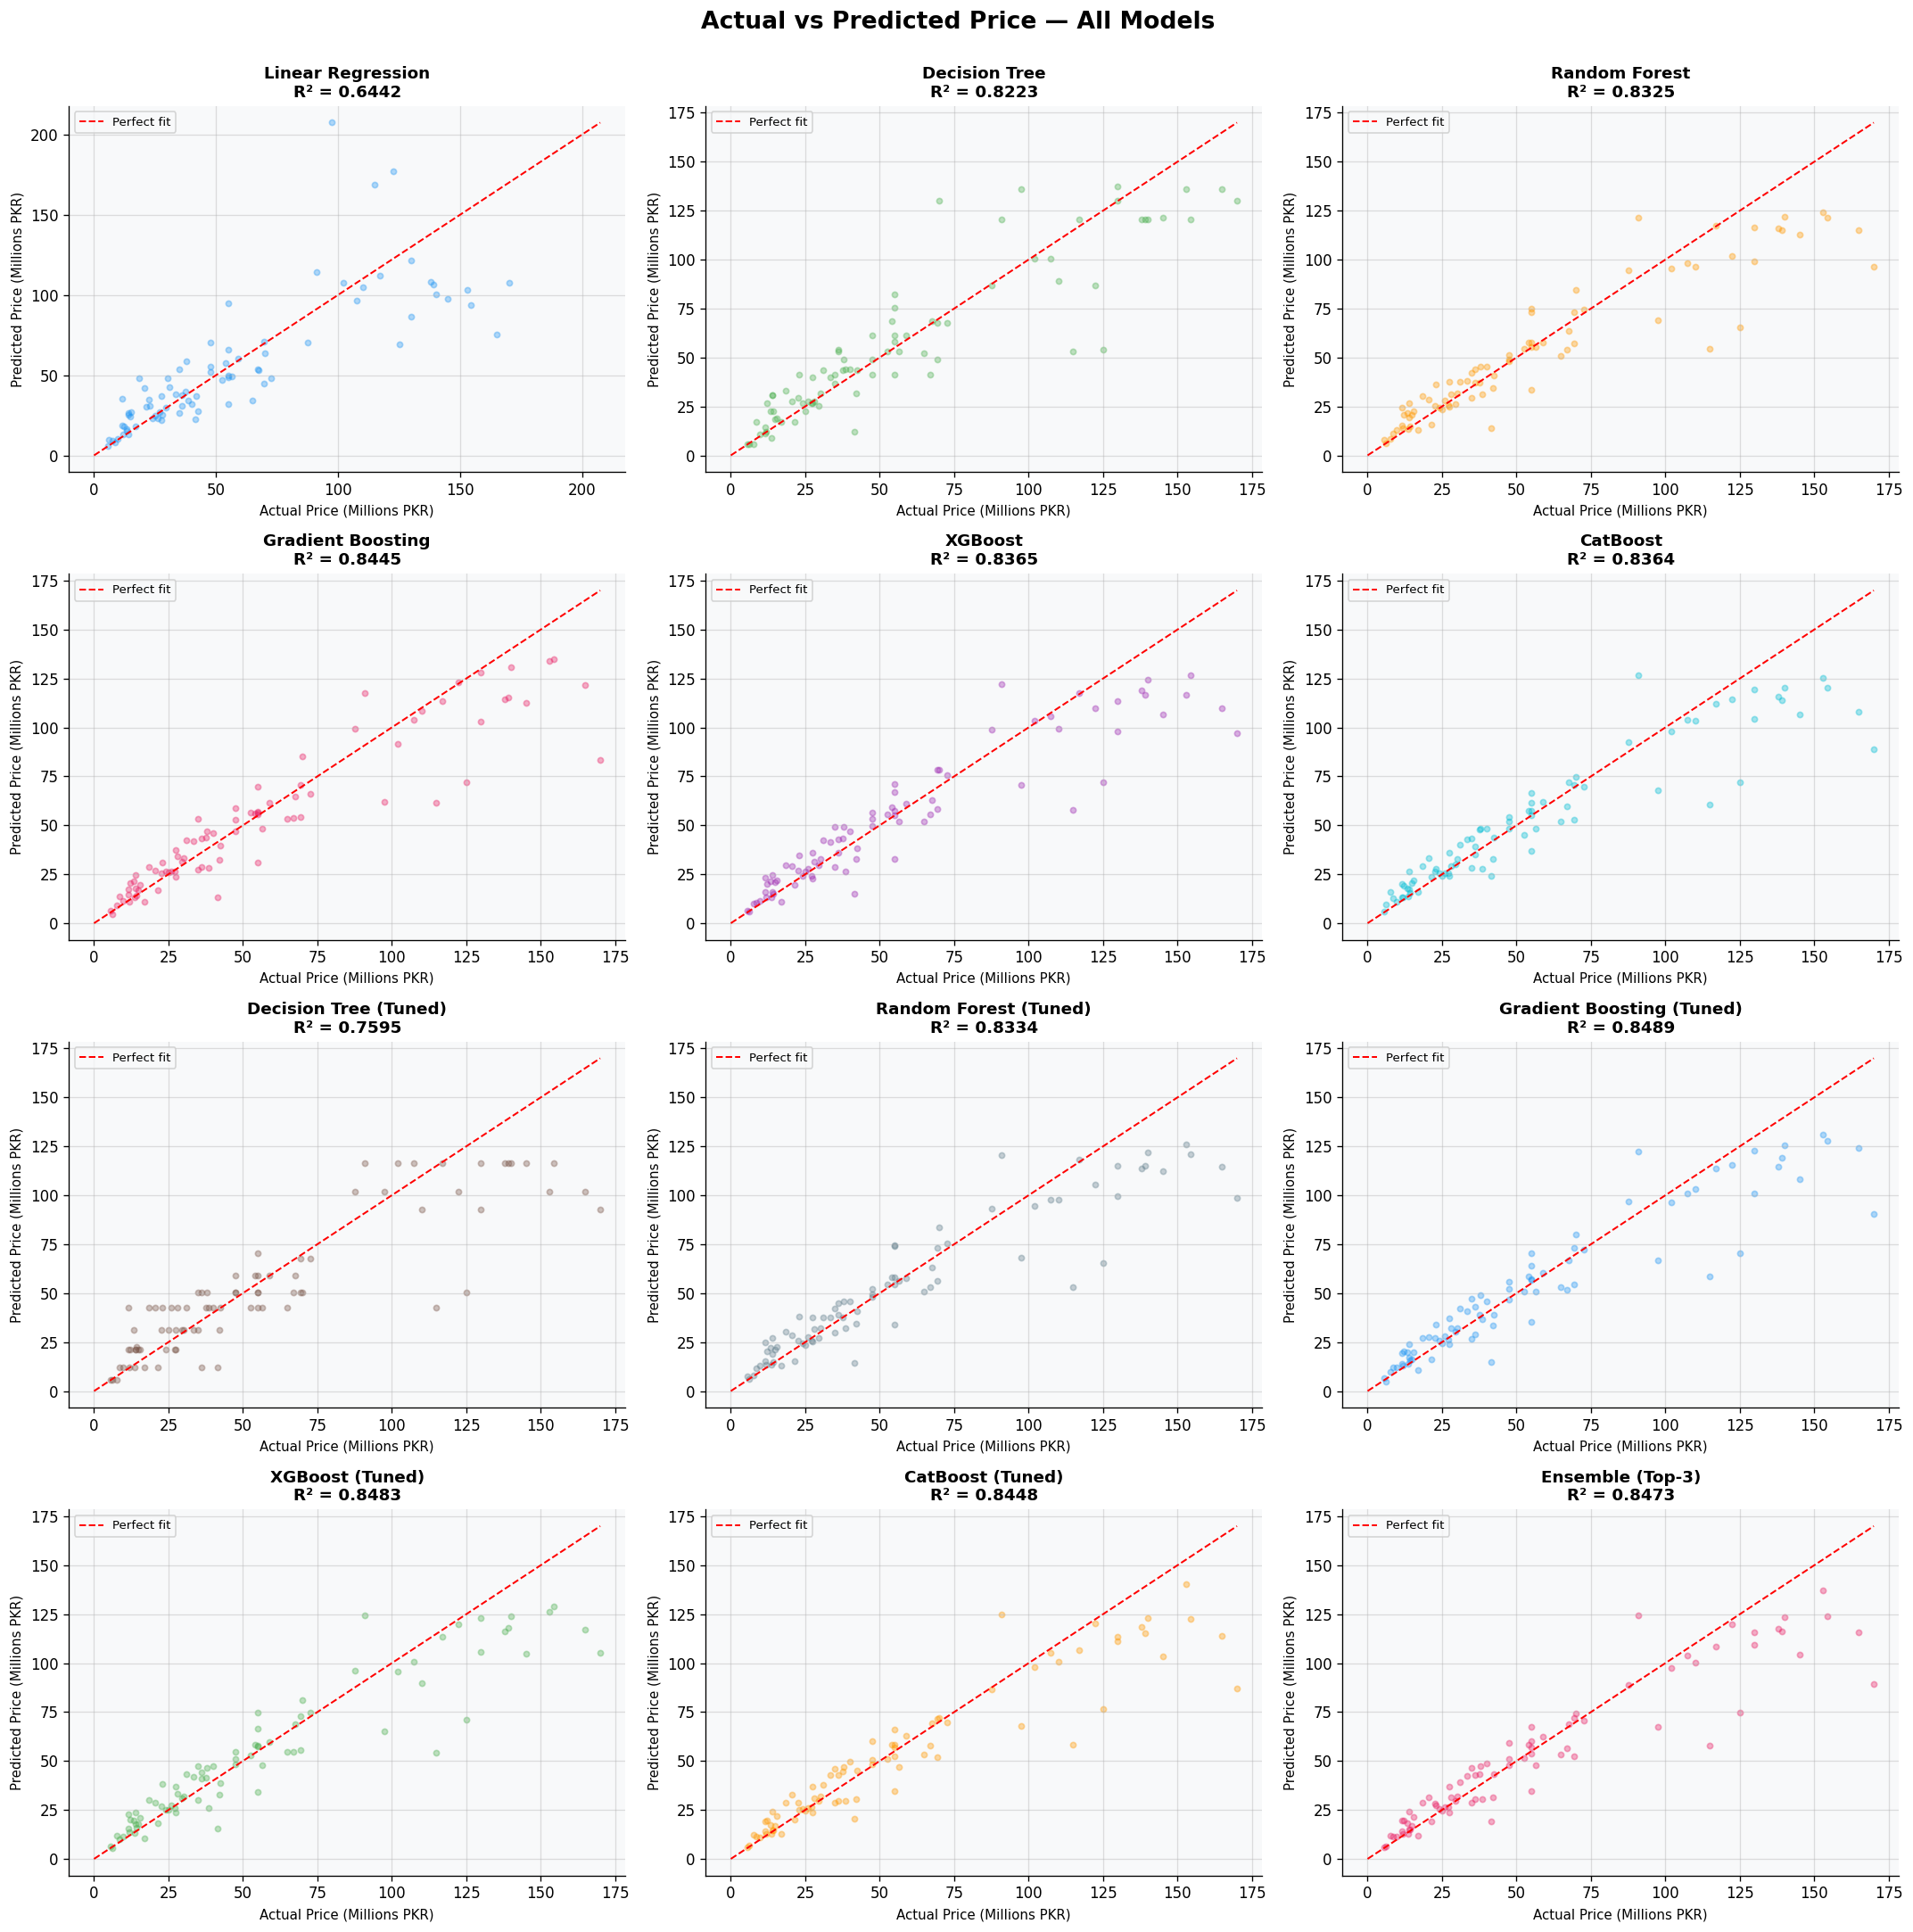

In [21]:
n_models = len(trained_models)
cols = 3
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
fig.suptitle('Actual vs Predicted Price — All Models',
             fontsize=16, fontweight='bold', y=1.00)
axes = axes.flatten()
for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    preds_log = model.predict(X_test)
    preds_pkr = np.expm1(preds_log) / 1e6
    actual_m  = ya_test.values / 1e6
    r2        = r2_score(ya_test.values, np.expm1(preds_log))
    ax.scatter(actual_m, preds_pkr, alpha=0.35, s=14,
               color=PALETTE[idx % len(PALETTE)])
    lim = max(actual_m.max(), preds_pkr.max())
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='Perfect fit')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual Price (Millions PKR)', fontsize=9)
    ax.set_ylabel('Predicted Price (Millions PKR)', fontsize=9)
    ax.legend(fontsize=8)
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()


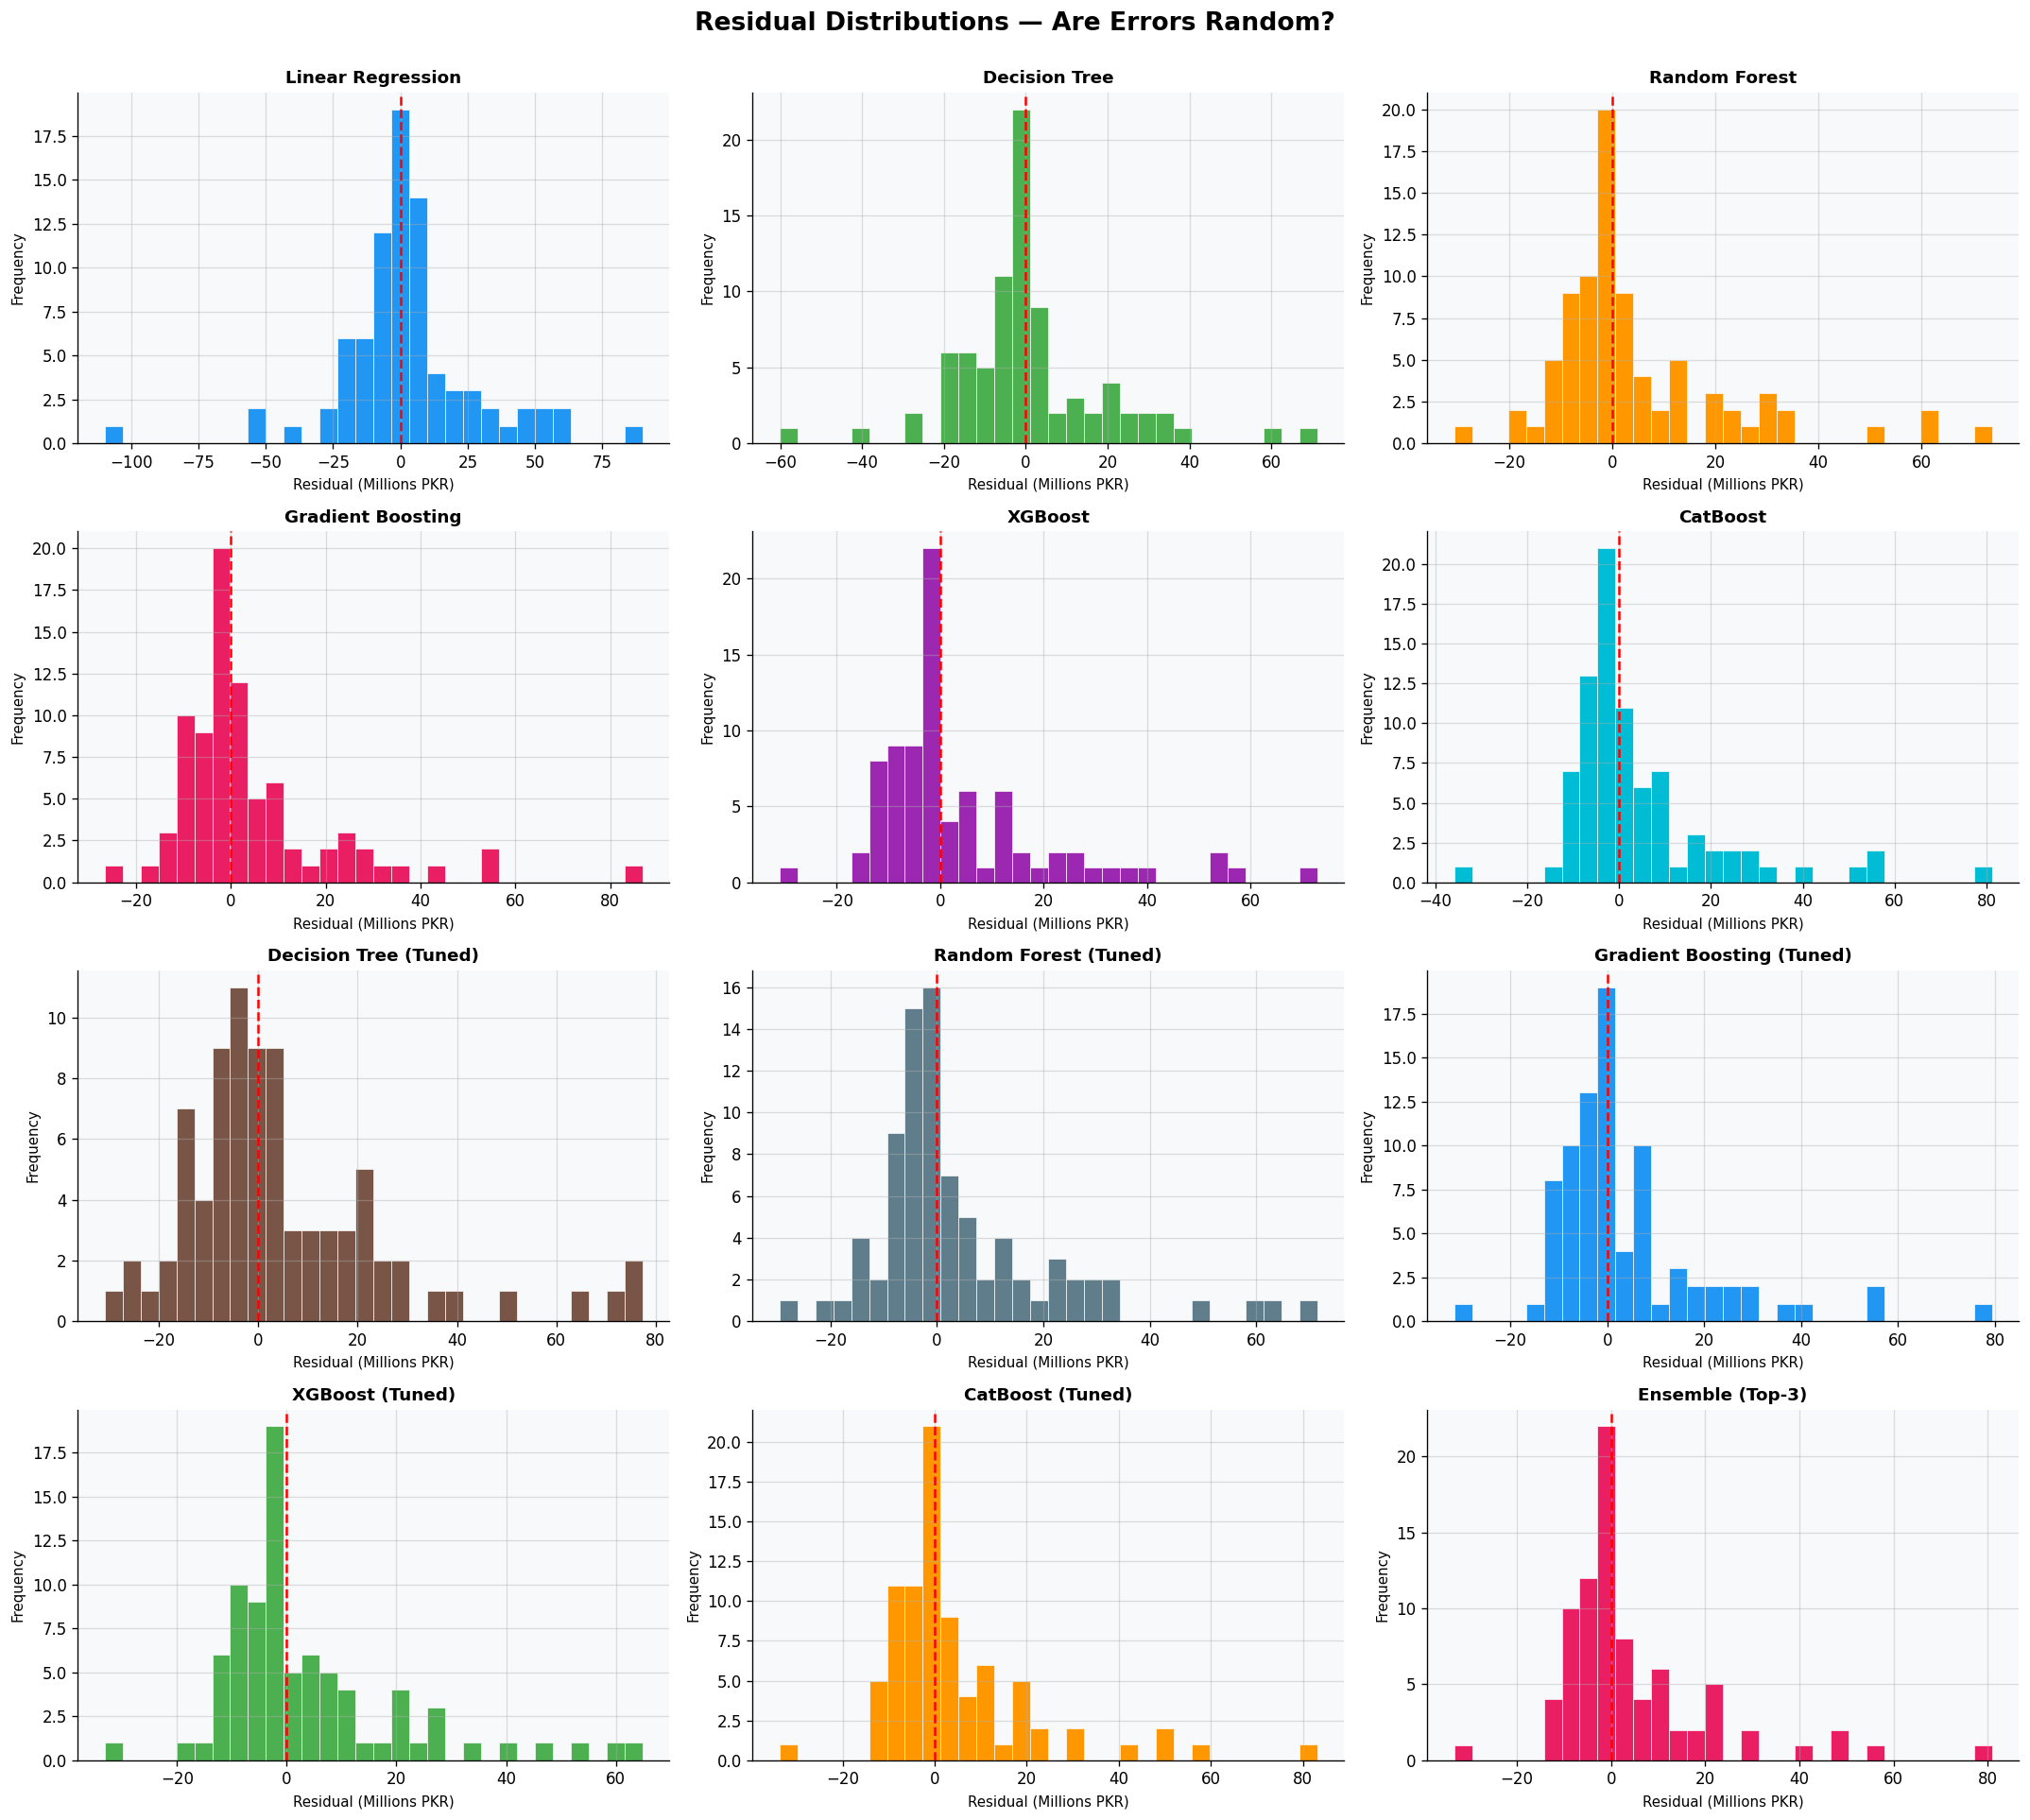

In [22]:
n_models = len(trained_models)
cols = 3
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
fig.suptitle('Residual Distributions — Are Errors Random?',
             fontsize=16, fontweight='bold', y=1.00)
axes = axes.flatten()
for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    preds_pkr   = np.expm1(model.predict(X_test))
    residuals_m = (ya_test.values - preds_pkr) / 1e6
    ax.hist(residuals_m, bins=30,
            color=PALETTE[idx % len(PALETTE)],
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Residual (Millions PKR)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()


### 4.3 — Feature Importance (Best Model)

Best Model: CatBoost (Tuned)
   R2 Score      : 0.9107
   CV R2 (5-fold): 0.7961
   RMSE          : 17.538 M PKR
   MAPE          : 19.69%


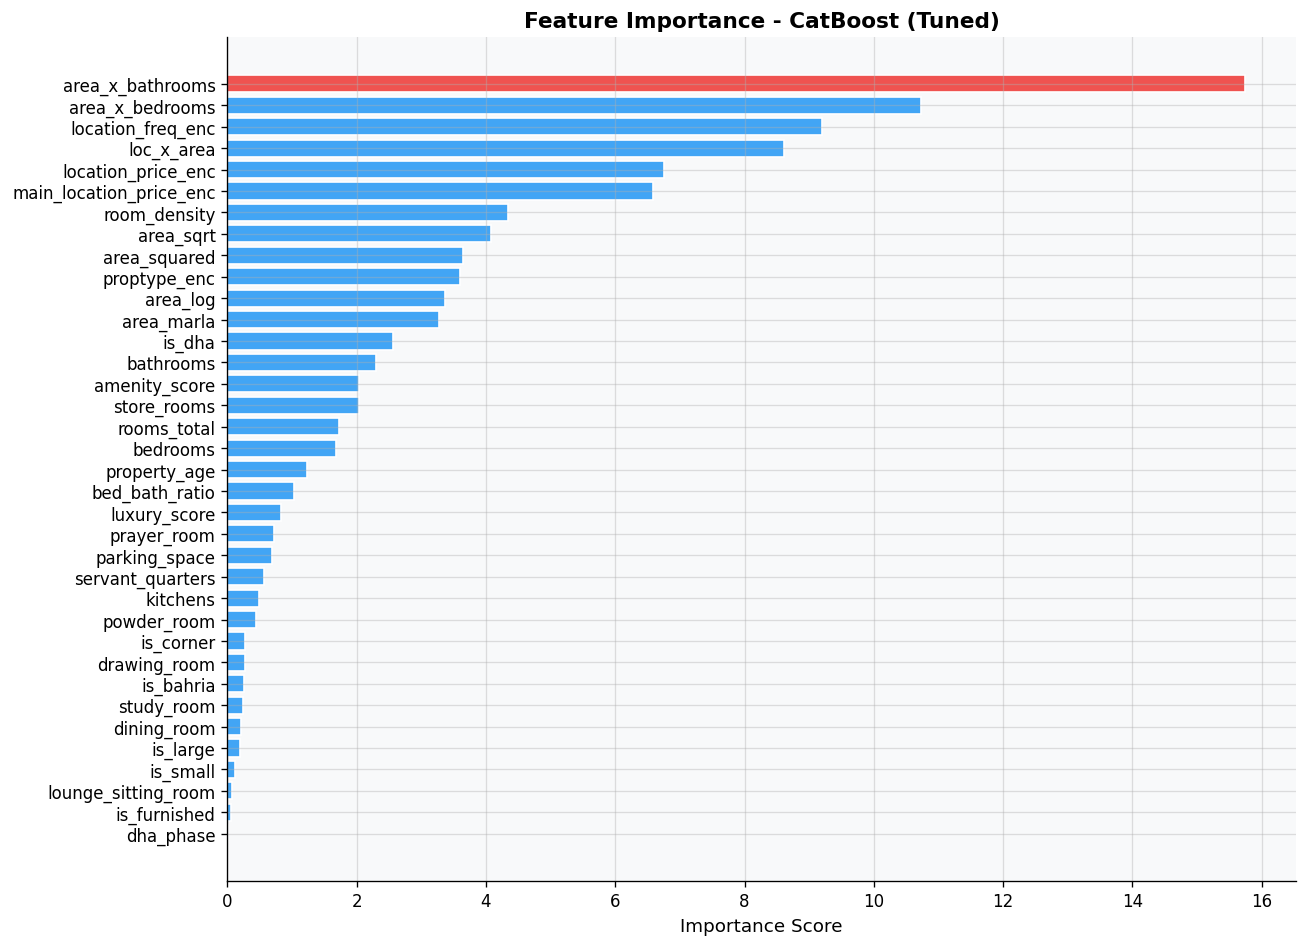

In [23]:
print(f'Best Model: {best_model_name}')
print(f'   R2 Score      : {results_df.iloc[0]["R2 Score"]}')
print(f'   CV R2 (5-fold): {results_df.iloc[0]["CV R2 (5-fold)"]}')
print(f'   RMSE          : {results_df.iloc[0]["RMSE (M PKR)"]} M PKR')
if 'MAPE %' in results_df.columns:
    print(f'   MAPE          : {results_df.iloc[0]["MAPE %"]}%')
importance_model = best_model
model_label = best_model_name
if hasattr(best_model, 'estimators_') and not hasattr(best_model, 'feature_importances_'):
    importance_model = best_model.estimators_[0]
    model_label = f'{best_model_name} (base: {type(importance_model).__name__})'
    print(f'\n(Showing feature importance from base estimator)')
if hasattr(importance_model, 'feature_importances_'):
    imp_df = (pd.DataFrame({
                  'Feature'   : FEATURE_COLS,
                  'Importance': importance_model.feature_importances_
              })
              .sort_values('Importance', ascending=True))
    fig, ax = plt.subplots(figsize=(11, 8))
    colors_fi = ['#ef5350' if imp_df['Importance'].values[-1] == v
                 else '#42a5f5' for v in imp_df['Importance'].values]
    ax.barh(imp_df['Feature'], imp_df['Importance'],
            color=colors_fi, edgecolor='white')
    ax.set_title(f'Feature Importance - {model_label}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print('(Feature importance not available for this model type)')


---
## CLO-5: End-to-End System Development
### 5.1 — Save Best Model

In [24]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
loc_median_map = df.groupby('location')['price_pkr'].mean().to_dict()                 if 'location' in df.columns else {}
with open('loc_median_map.pkl', 'wb') as f:
    pickle.dump(loc_median_map, f)
loc_freq_map = df['location'].value_counts(normalize=True).to_dict()               if 'location' in df.columns else {}
with open('loc_freq_map.pkl', 'wb') as f:
    pickle.dump(loc_freq_map, f)
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
global_median_price = df['price_pkr'].mean()
with open('global_median.pkl', 'wb') as f:
    pickle.dump(global_median_price, f)
print(f' Saved  best_model.pkl      -> {best_model_name}')
print( ' Saved  loc_median_map.pkl  -> location mean target encoder')
print( ' Saved  loc_freq_map.pkl    -> location frequency encoder')
print( ' Saved  feature_cols.pkl    -> feature list')
print( ' Saved  global_median.pkl   -> fallback mean price')


 Saved  best_model.pkl      -> CatBoost (Tuned)
 Saved  loc_median_map.pkl  -> location mean target encoder
 Saved  loc_freq_map.pkl    -> location frequency encoder
 Saved  feature_cols.pkl    -> feature list
 Saved  global_median.pkl   -> fallback mean price


### 5.2 — Prediction System
Enter property details below and get an estimated price.

In [25]:
def resolve_location_input(location):
    """Match short user text like 'F-10' to the full dataset location when possible."""
    location = str(location).strip()
    if location in loc_median_map:
        return location
    query = location.lower()
    for known_location in loc_median_map:
        if query and query in known_location.lower():
            return known_location
    return location
def build_input_vector(area_marla, bedrooms, bathrooms,
                       location, property_type='House',
                       built_year=2024,
                       parking=1, servants=0, stores=0, kitchen_count=1,
                       drawing=1, dining=1, study=0, prayer=0,
                       powder=0, lounge=1):
    """Converts user inputs into the feature vector the model was trained on."""
    location = resolve_location_input(location)
    main_location = location.split(',')[0].strip()
    loc_enc = loc_median_map.get(location, global_median_price)
    main_matches = [v for k, v in loc_median_map.items()
                    if k.split(',')[0].strip().lower() == main_location.lower()]
    main_loc_enc = float(np.mean(main_matches)) if main_matches else global_median_price
    loc_freq = loc_freq_map.get(location, 0)
    main_loc_freq = sum(v for k, v in loc_freq_map.items()
                        if k.split(',')[0].strip().lower() == main_location.lower())
    try:
        ptype_enc = le_type.transform([property_type])[0]
    except Exception:
        ptype_enc = 0
    area_sq       = area_marla ** 2
    area_lg       = np.log1p(area_marla)
    rooms_total   = bedrooms + bathrooms
    bed_bath_rat  = bedrooms / max(bathrooms, 1)
    is_large      = int(area_marla >= 10)
    is_small      = int(area_marla <= 5)
    area_x_bed    = area_marla * bedrooms
    area_x_bath   = area_marla * bathrooms
    rooms_x_area  = rooms_total * area_marla
    room_dens     = rooms_total / max(area_marla, 1)
    bed_per_marla = bedrooms / max(area_marla, 1)
    bath_per_marla = bathrooms / max(area_marla, 1)
    area_per_room = area_marla / max(rooms_total, 1)
    prop_age      = max(0, min(80, 2026 - built_year))
    amenity_score = parking + servants + stores + kitchen_count + drawing + dining + study + prayer + powder + lounge
    luxury_score  = servants + study + prayer + lounge + drawing
    amenity_density = amenity_score / max(area_marla, 1)
    luxury_density = luxury_score / max(area_marla, 1)
    loc_text = location.lower()
    row = {
        'area_marla'            : area_marla,
        'area_squared'          : area_sq,
        'area_log'              : area_lg,
        'bedrooms'              : bedrooms,
        'bathrooms'             : bathrooms,
        'rooms_total'           : rooms_total,
        'bed_bath_ratio'        : bed_bath_rat,
        'location_price_enc'    : loc_enc,
        'main_location_price_enc': main_loc_enc,
        'location_freq_enc'     : loc_freq,
        'main_location_freq_enc': main_loc_freq,
        'proptype_enc'          : ptype_enc,
        'is_large'              : is_large,
        'is_small'              : is_small,
        'amenity_score'         : amenity_score,
        'luxury_score'          : luxury_score,
        'amenity_density'       : amenity_density,
        'luxury_density'        : luxury_density,
        'area_x_bedrooms'       : area_x_bed,
        'area_x_bathrooms'      : area_x_bath,
        'rooms_x_area'          : rooms_x_area,
        'room_density'          : room_dens,
        'bedrooms_per_marla'    : bed_per_marla,
        'bathrooms_per_marla'   : bath_per_marla,
        'area_per_room'         : area_per_room,
        'property_age'          : prop_age,
        'is_new_property'       : int(prop_age <= 2),
        'is_recent_property'    : int(prop_age <= 5),
        'parking_per_marla'     : parking / max(area_marla, 1),
        'kitchens_per_room'     : kitchen_count / max(rooms_total, 1),
        'title_len'             : 0,
        'title_word_count'      : 0,
        'loc_word_count'        : len(loc_text.split()),
        'has_dha'               : int('dha' in loc_text or 'defence' in loc_text),
        'has_bahria'            : int('bahria' in loc_text),
        'has_gulberg'           : int('gulberg' in loc_text),
        'has_sector'            : int(any(word in loc_text for word in ['sector', 'phase', 'block'])),
        'has_luxury_word'       : 0,
        'has_corner'            : 0,
        'has_investor_word'     : 0,
    }
    return pd.DataFrame([row]).reindex(columns=FEATURE_COLS, fill_value=0)
def predict_price(area_marla, bedrooms, bathrooms,
                  location, property_type='House'):
    vec      = build_input_vector(area_marla, bedrooms,
                                  bathrooms, location, property_type)
    log_pred = best_model.predict(vec)[0]
    price    = max(0, np.expm1(log_pred))
    label = (f'{price/1e7:.2f} Crore PKR'
             if price >= 1e7 else f'{price/1e5:.2f} Lakh PKR')
    print('=' * 46)
    print(f'  Property    : {property_type} in {resolve_location_input(location)}')
    print(f'  Area        : {area_marla} Marla')
    print(f'  Bedrooms    : {bedrooms}')
    print(f'  Bathrooms   : {bathrooms}')
    print('  ' + '-' * 42)
    print(f'   Estimated Price : {label}')
    print('=' * 46)
    return price
print(f'Prediction system ready - using {best_model_name}')


Prediction system ready - using CatBoost (Tuned)


In [26]:
print('='*46)
print('  SAMPLE PREDICTIONS')
print('='*46)
test_queries = [
    (10,  4, 3, 'F-10',          'House'),
    (5,   3, 2, 'DHA Phase 2',   'House'),
    (1,   2, 1, 'G-11',          'Flat'),
    (20,  5, 4, 'F-7',           'House'),
    (3,   2, 2, 'Bahria Town',   'Apartment'),
]
for area, beds, baths, loc, ptype in test_queries:
    predict_price(area, beds, baths, loc, ptype)
    print()


  SAMPLE PREDICTIONS
  Property    : House in F-10, Islamabad, Islamabad Capital
  Area        : 10 Marla
  Bedrooms    : 4
  Bathrooms   : 3
  ------------------------------------------
   Estimated Price : 3.02 Crore PKR

  Property    : House in DHA Phase 2
  Area        : 5 Marla
  Bedrooms    : 3
  Bathrooms   : 2
  ------------------------------------------
   Estimated Price : 1.84 Crore PKR

  Property    : Flat in G-11, Islamabad, Islamabad Capital
  Area        : 1 Marla
  Bedrooms    : 2
  Bathrooms   : 1
  ------------------------------------------
   Estimated Price : 64.71 Lakh PKR

  Property    : House in F-7
  Area        : 20 Marla
  Bedrooms    : 5
  Bathrooms   : 4
  ------------------------------------------
   Estimated Price : 6.92 Crore PKR

  Property    : Apartment in Bahria Town, Islamabad, Islamabad Capital
  Area        : 3 Marla
  Bedrooms    : 2
  Bathrooms   : 2
  ------------------------------------------
   Estimated Price : 75.20 Lakh PKR



---
##  5.3 — Interactive Prediction (Enter Your Own Values)

In [27]:
MY_AREA          = 10      
MY_BEDROOMS      = 4
MY_BATHROOMS     = 3
MY_LOCATION      = 'F-10' 
MY_PROPERTY_TYPE = 'House'
predict_price(MY_AREA, MY_BEDROOMS, MY_BATHROOMS,
              MY_LOCATION, MY_PROPERTY_TYPE)


  Property    : House in F-10, Islamabad, Islamabad Capital
  Area        : 10 Marla
  Bedrooms    : 4
  Bathrooms   : 3
  ------------------------------------------
   Estimated Price : 3.02 Crore PKR


np.float64(30239879.208788183)

---
##  5.4 — Final Summary

In [28]:
print('='*60)
print('  AIC354 - ML Lab Final Project Summary')
print('='*60)
print(f'  Dataset size      : {len(df)} listings')
print(f'  Features used     : {len(FEATURE_COLS)}')
print(f'  Train / Test      : {len(X_train)} / {len(X_test)}')
print(f'  Best model        : {best_model_name}')
print(f'  Best R2 Score     : {results_df.iloc[0]["R2 Score"]}')
print(f'  Best RMSE         : {results_df.iloc[0]["RMSE (M PKR)"]} M PKR')
if 'MAPE %' in results_df.columns:
    print(f'  Best MAPE         : {results_df.iloc[0]["MAPE %"]}%')
print('='*60)
print('\nAll Model Results (sorted by R2):')
print(results_df.to_string())


  AIC354 - ML Lab Final Project Summary
  Dataset size      : 413 listings
  Features used     : 36
  Train / Test      : 330 / 83
  Best model        : CatBoost (Tuned)
  Best R2 Score     : 0.9107
  Best RMSE         : 17.538 M PKR
  Best MAPE         : 19.69%

All Model Results (sorted by R2):
                           MAE (M PKR)  MSE (M PKR^2)  RMSE (M PKR)  R2 Score  Accuracy % (R2)  CV R2 (5-fold)  MAPE %
Model                                                                                                                 
CatBoost (Tuned)                10.405        307.596        17.538    0.9107            91.07          0.7961   19.69
Ensemble (Top-3)                10.429        302.613        17.396    0.9095            90.95          0.9095   19.81
CatBoost                        10.861        324.296        18.008    0.9018            90.18          0.7884   21.54
Gradient Boosting (Tuned)       10.633        299.434        17.304    0.8989            89.89          0.8

TO see the clo-5 working please can see:
above for demo i use at last

also the gui is in seprate file 

---
___________________________________ END______________________________________
---
---